# Fisher Information Analysis and Model Cross-Fitting

Code used to run analysis and generate plots for "Mitigating effects of jitter through differentiable
forwards-modeling for the TOLIMAN space telescope".

In [1]:
import jax

# Enable 64bit precision (note this must be run in the first cell of the notebook)
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")

from jax import numpy as np, random as jr, Array
import zodiax as zdx
import dLux as dl
import dLuxToliman as dlT
import optax


import os
from tqdm.notebook import tqdm
import random
from datetime import datetime

# plotting
import matplotlib as mpl
from matplotlib import pyplot as plt
import scienceplots
import cmasher as cmr

plt.style.use(["science", "no-latex"])
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300

# Colour schemes
ito_seven = [
    "#0072B2",
    "#D55E00",
    "#009E73",
    "#CC79A7",
    "#56B4E9",
    "#E69F00",
    "#F0E442",
]
contrast_three = ["#004488", "#BB5566", "#DDAA33"]

Setting up the model.

## Priors

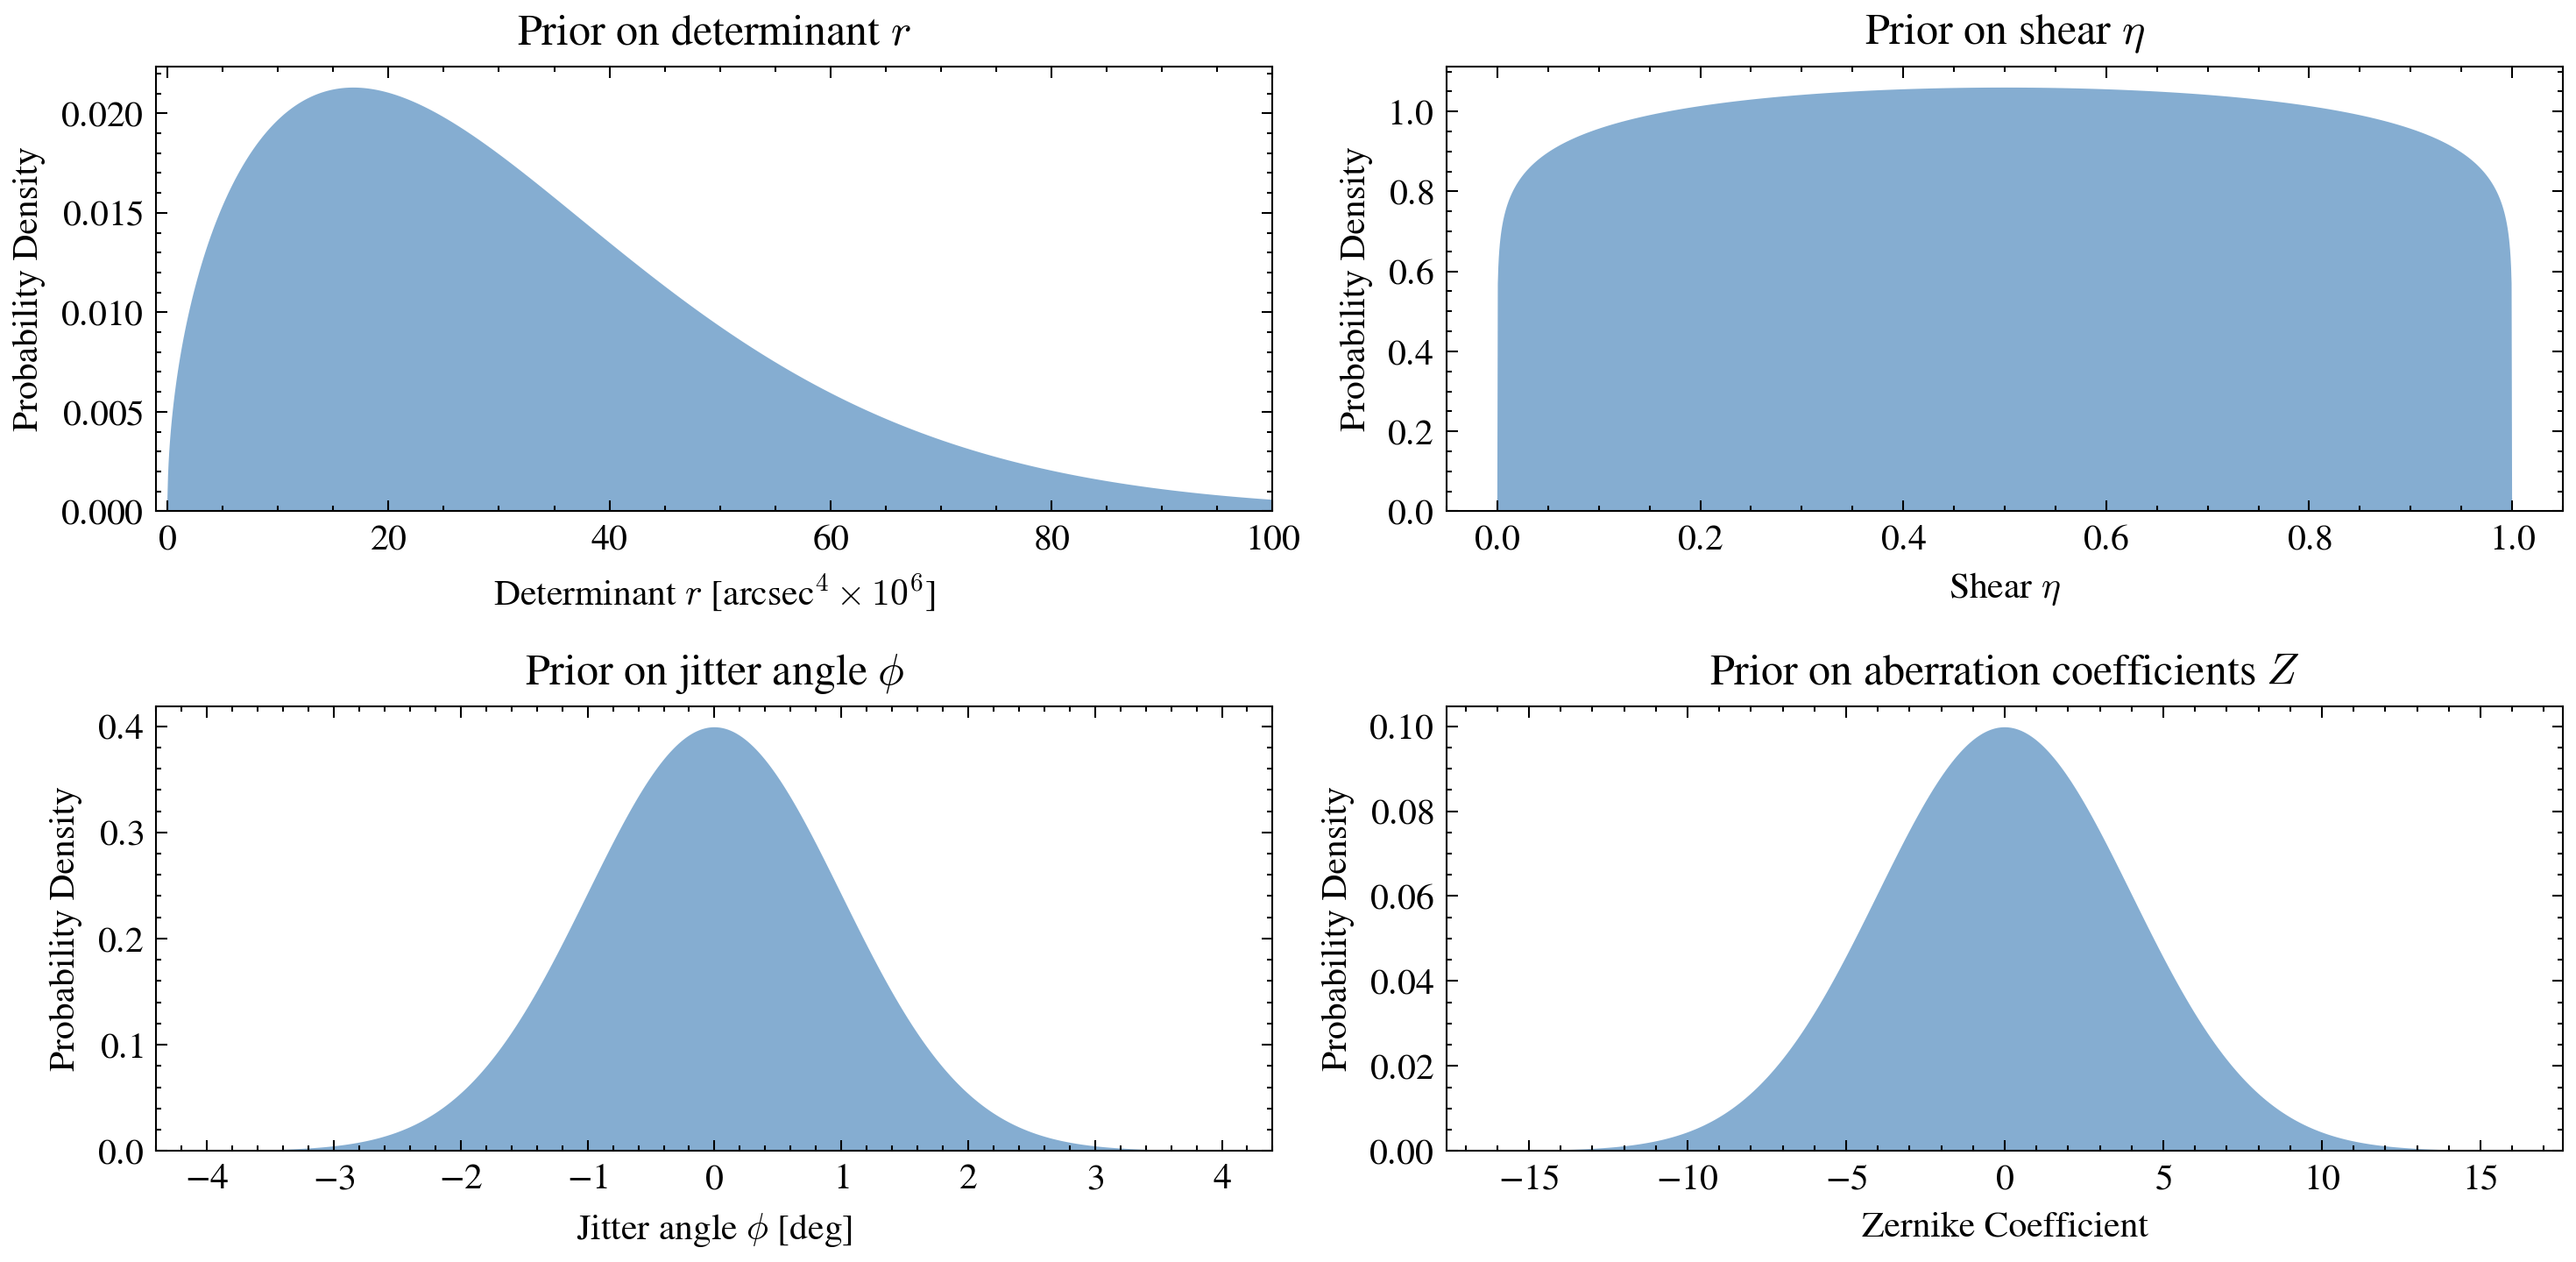

In [2]:
from jax.scipy.stats import norm, beta


def weibull_logpdf(x, k=1.5, lam=35):
    x = np.asarray(x)
    return np.log(k) - k * np.log(lam) + (k - 1) * np.log(x) - (x / lam) ** k


fig, ax = plt.subplots(2, 2, figsize=(10, 5))

xs = np.linspace(-1, 100, 2000)
ax[0][0].fill_between(xs, np.exp(weibull_logpdf(xs)), alpha=0.5)
ax[0][0].set(
    title=r"Prior on determinant $r$",
    xlabel=r"Determinant $r$ [arcsec$^4 \times10^{6}$]",
    ylabel="Probability Density",
    xlim=(-1, 100),
    ylim=(0, None),
)

xs = np.linspace(0, 1, 2000)
ax[0][1].fill_between(xs, beta.pdf(xs, a=1.1, b=1.1), alpha=0.5)
ax[0][1].set(
    title=r"Prior on shear $\eta$",
    xlabel=r"Shear $\eta$",
    ylabel="Probability Density",
    ylim=(0, None),
)

xs = np.linspace(-4, 4, 2000)
ax[1][0].fill_between(xs, norm.pdf(x=xs, loc=0, scale=1.0), alpha=0.5)
ax[1][0].set(
    title=r"Prior on jitter angle $\phi$",
    xlabel=r"Jitter angle $\phi$ [deg]",
    ylabel="Probability Density",
    ylim=(0, None),
)


xs = np.linspace(-16, 16, 2000)
ax[1][1].fill_between(xs, norm.pdf(x=xs, loc=0, scale=4.0), alpha=0.5)
ax[1][1].set(
    title=r"Prior on aberration coefficients $Z$",
    xlabel=r"Zernike Coefficient",
    ylabel="Probability Density",
    ylim=(0, None),
)
plt.tight_layout()
plt.show()

In [3]:
import jax
from jax import numpy as np, scipy as jsp, Array

jax.config.update("jax_enable_x64", True)

import zodiax as zdx
from zodiax import filter_vmap

import dLuxToliman as dlT
import dLux
from dLuxToliman import AlphaCen

Source = lambda: dLux.BaseSource
Optics = lambda: dLux.BaseOpticalSystem


def fwhm_to_det(fwhm, shear):
    return 1e6 * (1 - shear) ** 2 * (fwhm / 2.35482) ** 4


def det_to_fwhm(det, shear):
    return 2.35482 * ((det / 1e6) / (1 - shear) ** 2) ** 0.25


def powspace(start, stop, power, num):
    """
    To generate r values at appropriate intervals.
    """
    start = np.power(start, 1 / float(power))
    stop = np.power(stop, 1 / float(power))
    return np.power(np.linspace(start, stop, num=num), power)


def prior_fn(model, args={}):

    prior = 0

    if isinstance(model, dlT.JitteredToliman):
        # jitter angle phi
        angle = model.get("jitter_angle")
    elif isinstance(model, dlT.Toliman):
        # determinant r
        det = model.get("Jitter.r")
        prior += weibull_logpdf(det)

        # shear
        shear = model.get("Jitter.shear")
        prior += beta.logpdf(shear, a=1.1, b=1.1)

        # jitter angle phi
        angle = model.get("Jitter.phi")
    prior += norm.logpdf(x=angle, loc=args["angle"], scale=1.0)

    # aberration coefficients Z
    aberrations = model.get("aperture.coefficients")
    prior += norm.logpdf(x=aberrations, loc=0.0, scale=4.0).sum()

    return prior


angle = 0.0
mag = 0.5 * 0.375
shear = 0.1
r = fwhm_to_det(0.5 * 0.375, 0.1)
oversample = 4
mvn_osamp = 6
det_pscale = 0.375
det_npixels = 128
kernel_size = 17
n_psfs = 5


lin_params = {
    "jitter_mag": mag,
    "jitter_angle": angle,
    "jitter_shape": "linear",
    "n_psfs": n_psfs,
}
shm_params = {
    "jitter_mag": mag,
    "jitter_angle": angle,
    "jitter_shape": "shm",
    "n_psfs": n_psfs,
}
mvn_params = {"r": r, "shear": shear, "phi": angle, "kernel_size": kernel_size}
radial_orders = [2, 3]

# Creating common optical system
print("Building the models...")
optics = dlT.TolimanOpticalSystem(
    oversample=oversample,
    psf_npixels=det_npixels,
    radial_orders=radial_orders,
    psf_pixel_scale=det_pscale,
)
optics = optics.divide("aperture.basis", 1e9)  # Set basis units to nanometers
mvn_optics = optics.set("oversample", mvn_osamp)

# Creating common source
src = AlphaCen(
    separation=np.array(10.0),
    position_angle=np.array(90.0),
    x_position=np.array(0.0),
    y_position=np.array(0.0),
    log_flux=np.array(7.581),
    contrast=np.array(3.37),
)

# creating telescopes
lin_det = dLux.LayeredDetector([("Downsample", dLux.Downsample(oversample))])
shm_det = lin_det
mvn_det = dLux.LayeredDetector(
    [
        ("Jitter", dlT.GaussianJitter(**mvn_params)),
        ("Downsample", dLux.Downsample(mvn_osamp)),
    ]
)

# creating models
lin_tel = dlT.JitteredToliman(source=src, optics=optics, **lin_params).set(
    "detector", lin_det
)
shm_tel = dlT.JitteredToliman(source=src, optics=optics, **shm_params).set(
    "detector", shm_det
)
mvn_tel = dlT.Toliman(source=src, optics=mvn_optics).set("detector", mvn_det)

# creating simulated data at a high oversample
print("Creating simulated data grid...")
# dlin_tel = lin_tel.set(["oversample", "Downsample.kernel_size"], [8, 8])
dlin_tel = lin_tel
lin_datas = []

# dshm_tel = shm_tel.set(["oversample", "Downsample.kernel_size"], [8, 8])
dshm_tel = shm_tel
shm_datas = []

# dmvn_tel = mvn_tel.set(["oversample", "Downsample.kernel_size"], [8, 8])
dmvn_tel = mvn_tel
mvn_datas = []

for ang in np.linspace(0, 90, 5):
    for mag in np.linspace(0.375 / 5, 0.375 / 1, 5):
        dlin_tel = dlin_tel.set("jitter_mag", mag).set("jitter_angle", ang)
        lin_data = {
            "params": ["jitter_mag", "jitter_angle"],
            "values": [mag, ang],
            "data": dlin_tel.jitter_model(),
        }
        lin_datas.append(lin_data)

        dshm_tel = dshm_tel.set("jitter_mag", mag).set("jitter_angle", ang)
        shm_data = {
            "params": ["jitter_mag", "jitter_angle"],
            "values": [mag, ang],
            "data": dshm_tel.jitter_model(),
        }
        shm_datas.append(shm_data)

    for r in np.linspace(fwhm_to_det(0.375 / 5, 0.1), fwhm_to_det(0.375 / 1, 0.1), 5):
        dmvn_tel = dmvn_tel.set("Jitter.r", r).set("Jitter.phi", ang)
        mvn_data = {
            "params": ["Jitter.r", "Jitter.phi"],
            "values": [r, ang],
            "data": dmvn_tel.model(),
        }
        mvn_datas.append(mvn_data)

# NOTE make sure to ROUND data before passing here.
likelihood_fn = lambda model, data: jsp.stats.poisson.logpmf(data, model.jitter_model())

posterior_fn = lambda model, data, args: likelihood_fn(model, data).sum() + prior_fn(
    model, args
)

mvn_likelihood_fn = lambda model, data: jsp.stats.poisson.logpmf(data, model.model())

mvn_posterior_fn = lambda model, data, args: mvn_likelihood_fn(
    model, data
).sum() + prior_fn(model, args)

# Wrapping everything up and returning
models = {"lin": lin_tel, "shm": shm_tel, "mvn": mvn_tel}
loglike_fns = {
    "lin": likelihood_fn,
    "shm": likelihood_fn,
    "mvn": mvn_likelihood_fn,
}
posterior_fns = {
    "lin": posterior_fn,
    "shm": posterior_fn,
    "mvn": mvn_posterior_fn,
}
datas = {
    "lin": lin_datas,
    "shm": shm_datas,
    "mvn": mvn_datas,
}

common_params = [
    "separation",
    "position_angle",
    "x_position",
    "y_position",
    "log_flux",
    "contrast",
    # "wavelengths",
    # "psf_pixel_scale",
]

lin_params = [
    "jitter_mag",
    "jitter_angle",
    "aperture.coefficients",
]

mvn_params = [
    "Jitter.r",
    "Jitter.shear",
    "Jitter.phi",
    "aperture.coefficients",
]

params = {
    "lin": common_params + lin_params,
    "shm": common_params + lin_params,
    "mvn": common_params + mvn_params,
}

Building the models...
Creating simulated data grid...


## Model Cross-Fitting

The code for model cross-fitting to investigate systematic model-introduced bias and a potential increase in separation error.

In [4]:
from setup_jitter import plot_losses  # , summarise_fit
from matplotlib import colors, colormaps


def summarise_fit(
    model,
    data,
    args,
    loglike_fn,
):

    inferno = colormaps["inferno"]
    seismic = colormaps["seismic"]
    inferno.set_bad("k", 0.5)
    seismic.set_bad("k", 0.5)

    sim = model.model()
    residual = data - sim

    loglike_im = loglike_fn(model, data)
    final_loss = np.nanmean(-loglike_im)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.title(f"Pixel neg log posterior: {final_loss:,.1f}")
    plt.imshow(-loglike_im, cmap="viridis")
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.title("Mean noise mvnalised slope residual")
    plt.imshow(residual, cmap=seismic, norm=colors.CenteredNorm())
    plt.colorbar()

    plt.tight_layout()
    plt.show()

    if not isinstance(model, dlT.JitteredToliman):
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.title(f"Simulation")
        plt.imshow(sim, cmap="inferno")
        plt.colorbar()

        plt.subplot(1, 2, 2)
        plt.title("Convolution Kernel")
        plt.imshow(
            model.Jitter.generate_kernel(1.00),
            cmap="cividis",
            norm=mpl.colors.LogNorm(),
        )
        plt.colorbar()

        plt.tight_layout()
        plt.show()


def run_grad_desc(
    model,
    data,
    args,
    optimisers: dict,
    posterior_fn,
    likelihood_im_fn,
    norm_fn=lambda model, args: model,
    grad_fn=lambda grads, args: grads,
    iters=100,
    plot=False,
    verbose=True,
    eps=None,  # termination condition
):
    """
    Run gradient descent on a model.
    """

    # run gradient descent
    params = list(optimisers.keys())
    optim, opt_state = zdx.get_optimiser(model, params, list(optimisers.values()))
    losses, models_out = [], []

    @zdx.filter_jit
    @zdx.filter_value_and_grad(list(optimisers.keys()))
    def loss_func(model, data, args):
        return -posterior_fn(model, data, args).sum()

    norm_fn = zdx.filter_jit(norm_fn)
    # grad_fn = zdx.filter_jit(grad_fn)

    if verbose:
        t = tqdm(range(iters), desc="Gradient Descent")
    else:
        t = range(iters)

    for i in t:

        # for termination condition
        last_params = model.get(params)

        loss, grads = loss_func(model, np.round(data), args)
        grads = grad_fn(grads, args)

        # print(grads)

        updates, opt_state = optim.update(grads, opt_state)
        model = zdx.apply_updates(model, updates)
        model = norm_fn(model, args)

        models_out.append(model)
        losses.append(loss)

        if verbose:
            t.set_description("Loss: {:.6e}".format(loss))  # update the progress bar

        # Termination condition
        new_params = model.get(params)  # getting new parameters
        scaled_diffs = jax.tree.map(
            lambda x, y: np.abs((x - y) / y),
            last_params,
            new_params,
        )
        if eps is not None and i > 5:
            if np.all(
                np.array(  # if all parameters have converged
                    jax.tree.map(lambda x: np.all(x < eps), scaled_diffs)
                )
            ):
                print("Converged early")
                break

    if plot:
        plot_losses(losses, 10)
        summarise_fit(model, data, args, likelihood_im_fn)

        params_in = params
        for p in np.arange(0, len(params), 2):
            plt.figure(figsize=(10, 3))
            plt.subplot(1, 2, 1)

            param = params_in[p]
            param_out = np.array([m.get(param) for m in models_out])

            if param_out.size // iters > 1:
                plt.plot(range(i + 1), param_out - param_out[0], label=param)
            else:
                plt.plot(range(i + 1), param_out, label=param)
            plt.xlabel("Epoch")
            plt.legend()
            plt.ticklabel_format(style="plain", axis="both", useOffset=False)

            plt.subplot(1, 2, 2)
            if p + 1 == len(params_in):
                plt.tight_layout()
                plt.show()
                break

            param = params_in[p + 1]
            param_out = np.array([m.get(param) for m in models_out])

            if param_out.size // iters > 1:
                plt.plot(range(i + 1), param_out - param_out[0], label=param)
            else:
                plt.plot(range(i + 1), param_out, label=param)

            plt.xlabel("Epoch")
            plt.legend()
            plt.ticklabel_format(style="plain", axis="both", useOffset=False)

            plt.tight_layout()
            plt.show()

    return models_out[-1]

In [5]:
# TODO JIT THESE


def grad_fn(grads, args={}):

    # if mvn model
    data_dict, model_key, data_key, optimisers = (
        args["data_dict"],
        args["model_key"],
        args["data_key"],
        args["optimisers"].keys(),
    )
    # if model_key != "mvn" and data_key == "norm":
    #     grads = grads.multiply("jitter_mag", np.array(2e-2))

    if model_key == "norm":

        det = data_dict["values"][0]

        if data_key == "norm":
            grads = (
                grads.multiply("Jitter.r", np.array(1e-1))
                if "Jitter.r" in optimisers
                else grads
            )
            grads = (
                grads.multiply("Jitter.shear", np.array(5e0))
                if "Jitter.shear" in optimisers
                else grads
            )
        else:
            grads = (
                grads.multiply("Jitter.r", np.array(2e-3))
                if "Jitter.r" in optimisers
                else grads
            )
            grads = (
                grads.multiply("Jitter.r", np.array(1e2 * det))
                if "Jitter.r" in optimisers
                else grads
            )

            if det > 0.25:
                grads = (
                    grads.multiply("Jitter.shear", np.array(0.15))
                    if "Jitter.shear" in optimisers
                    else grads
                )
            if det > 0.31:
                grads = (
                    grads.multiply("Jitter.shear", np.array(0.4))
                    if "Jitter.shear" in optimisers
                    else grads
                )
    return grads


def norm_fn(model, args={}):

    print("Compiling norm_fn...")

    # if norm model
    data_dict, model_key, data_key = (
        args["data_dict"],
        args["model_key"],
        args["data_key"],
    )

    # clipping shear
    if model_key == "norm":
        shear = model.get("Jitter.shear")
        shear = np.clip(shear, 1e-8, 1 - 1e-4)
        model = model.set("Jitter.shear", shear)

        det = model.get("Jitter.r")
        det = np.clip(det, min=1e-16, max=None)
        model = model.set("Jitter.r", det)

    return model

In [6]:
# l = models["lin"]

# raw = l.model()
# # plt.imshow(raw)
# # plt.colorbar()
# # plt.show()

# l = l.set("jitter_angle", np.array(90.0)).set("jitter_mag", np.array(1.0))
# arr = l.jitter_model()
# plt.figure(figsize=(10, 3))
# plt.subplot(1, 2, 1)
# plt.imshow(arr)
# plt.colorbar()
# plt.subplot(1, 2, 2)
# plt.imshow(raw - arr, "seismic", norm=mpl.colors.CenteredNorm())
# plt.colorbar()
# plt.show()

# n = models["norm"]
# n = (
#     n.set("Jitter.phi", np.array(90.0))
#     .set("Jitter.r", np.array(1.0))
#     .set("Jitter.shear", np.array(0.98))
#     .set("Jitter.kernel_size", 31)
# )
# arr = n.model()
# plt.figure(figsize=(10, 3))
# plt.subplot(1, 2, 1)
# plt.imshow(arr)
# plt.colorbar()
# plt.subplot(1, 2, 2)
# plt.imshow(raw - arr, "seismic", norm=mpl.colors.CenteredNorm())
# plt.colorbar()
# plt.show()

Models:   0%|          | 0/3 [00:00<?, ?it/s]

Data Arrays:   0%|          | 0/3 [00:00<?, ?it/s]

Noise Realisations:   0%|          | 0/5 [00:00<?, ?it/s]

lin lin Realisation 1/5 ['jitter_mag', 'jitter_angle'] [Array(0.075, dtype=float64), Array(0., dtype=float64)]


Gradient Descent:   0%|          | 0/100 [00:00<?, ?it/s]

Compiling norm_fn...


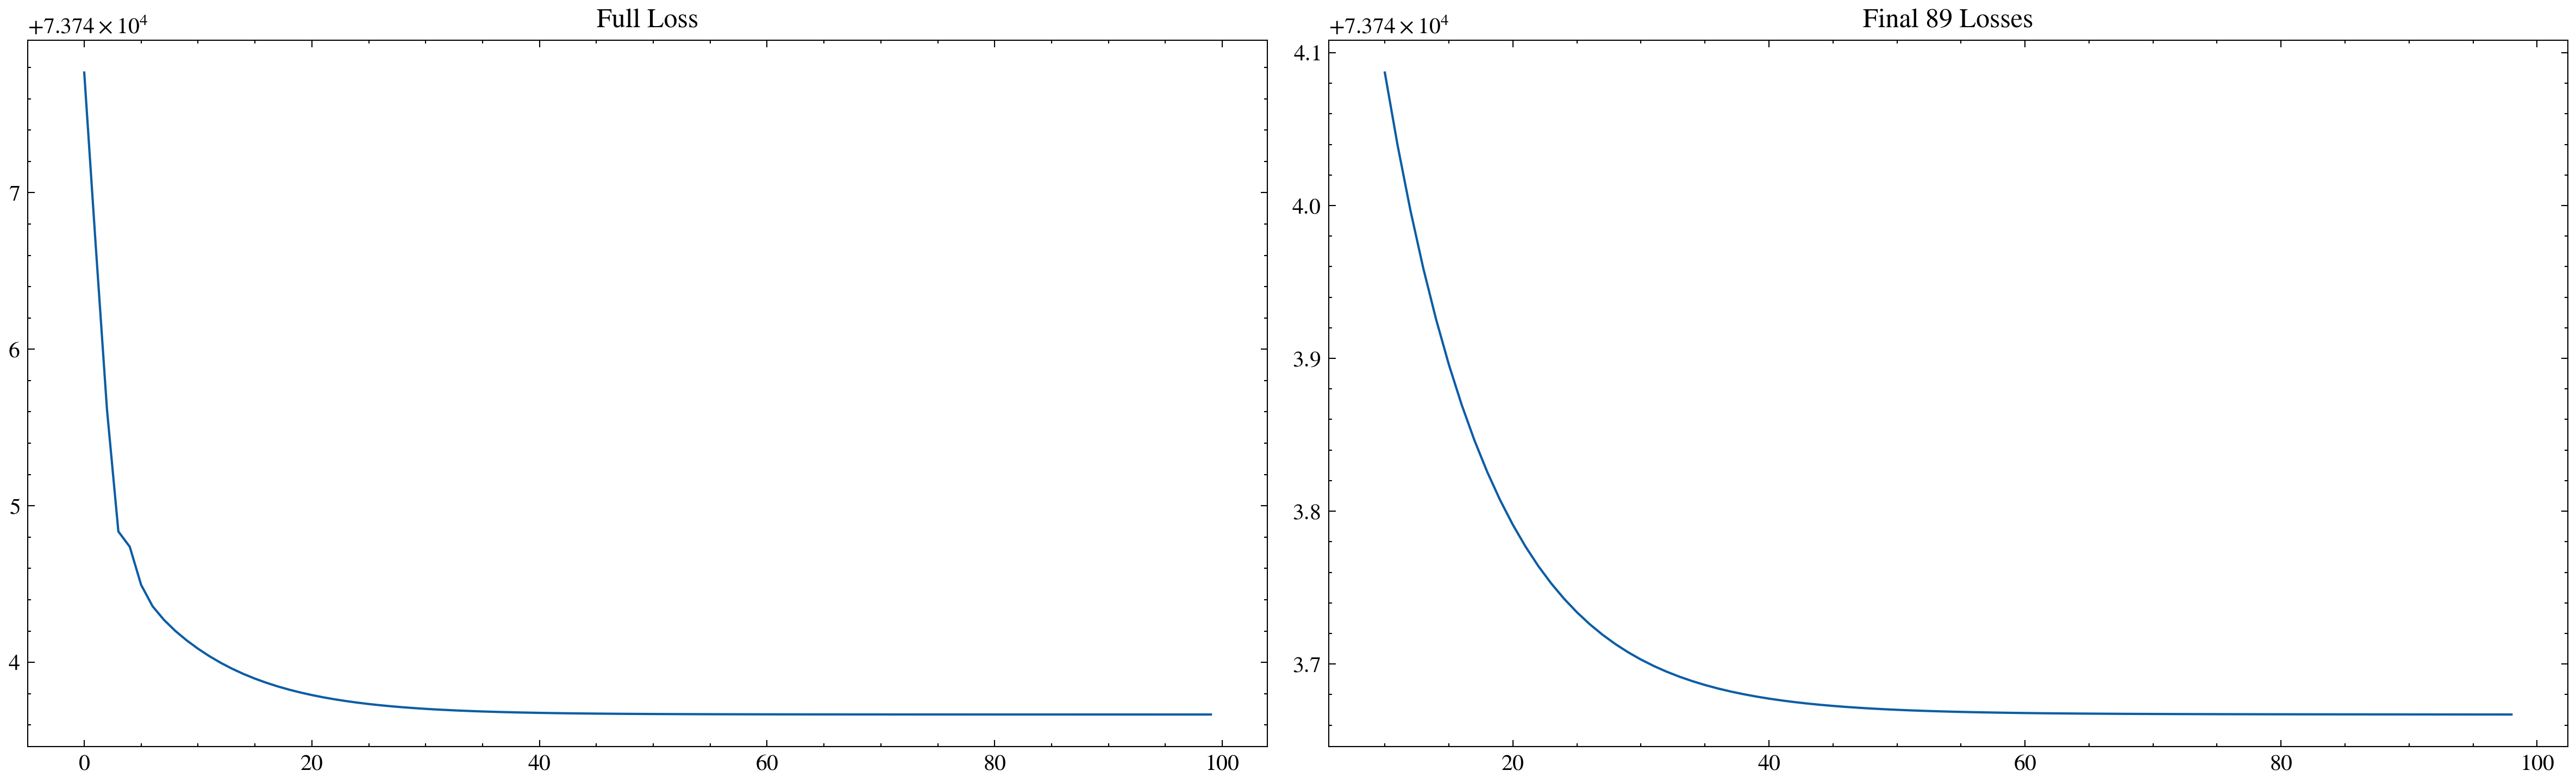

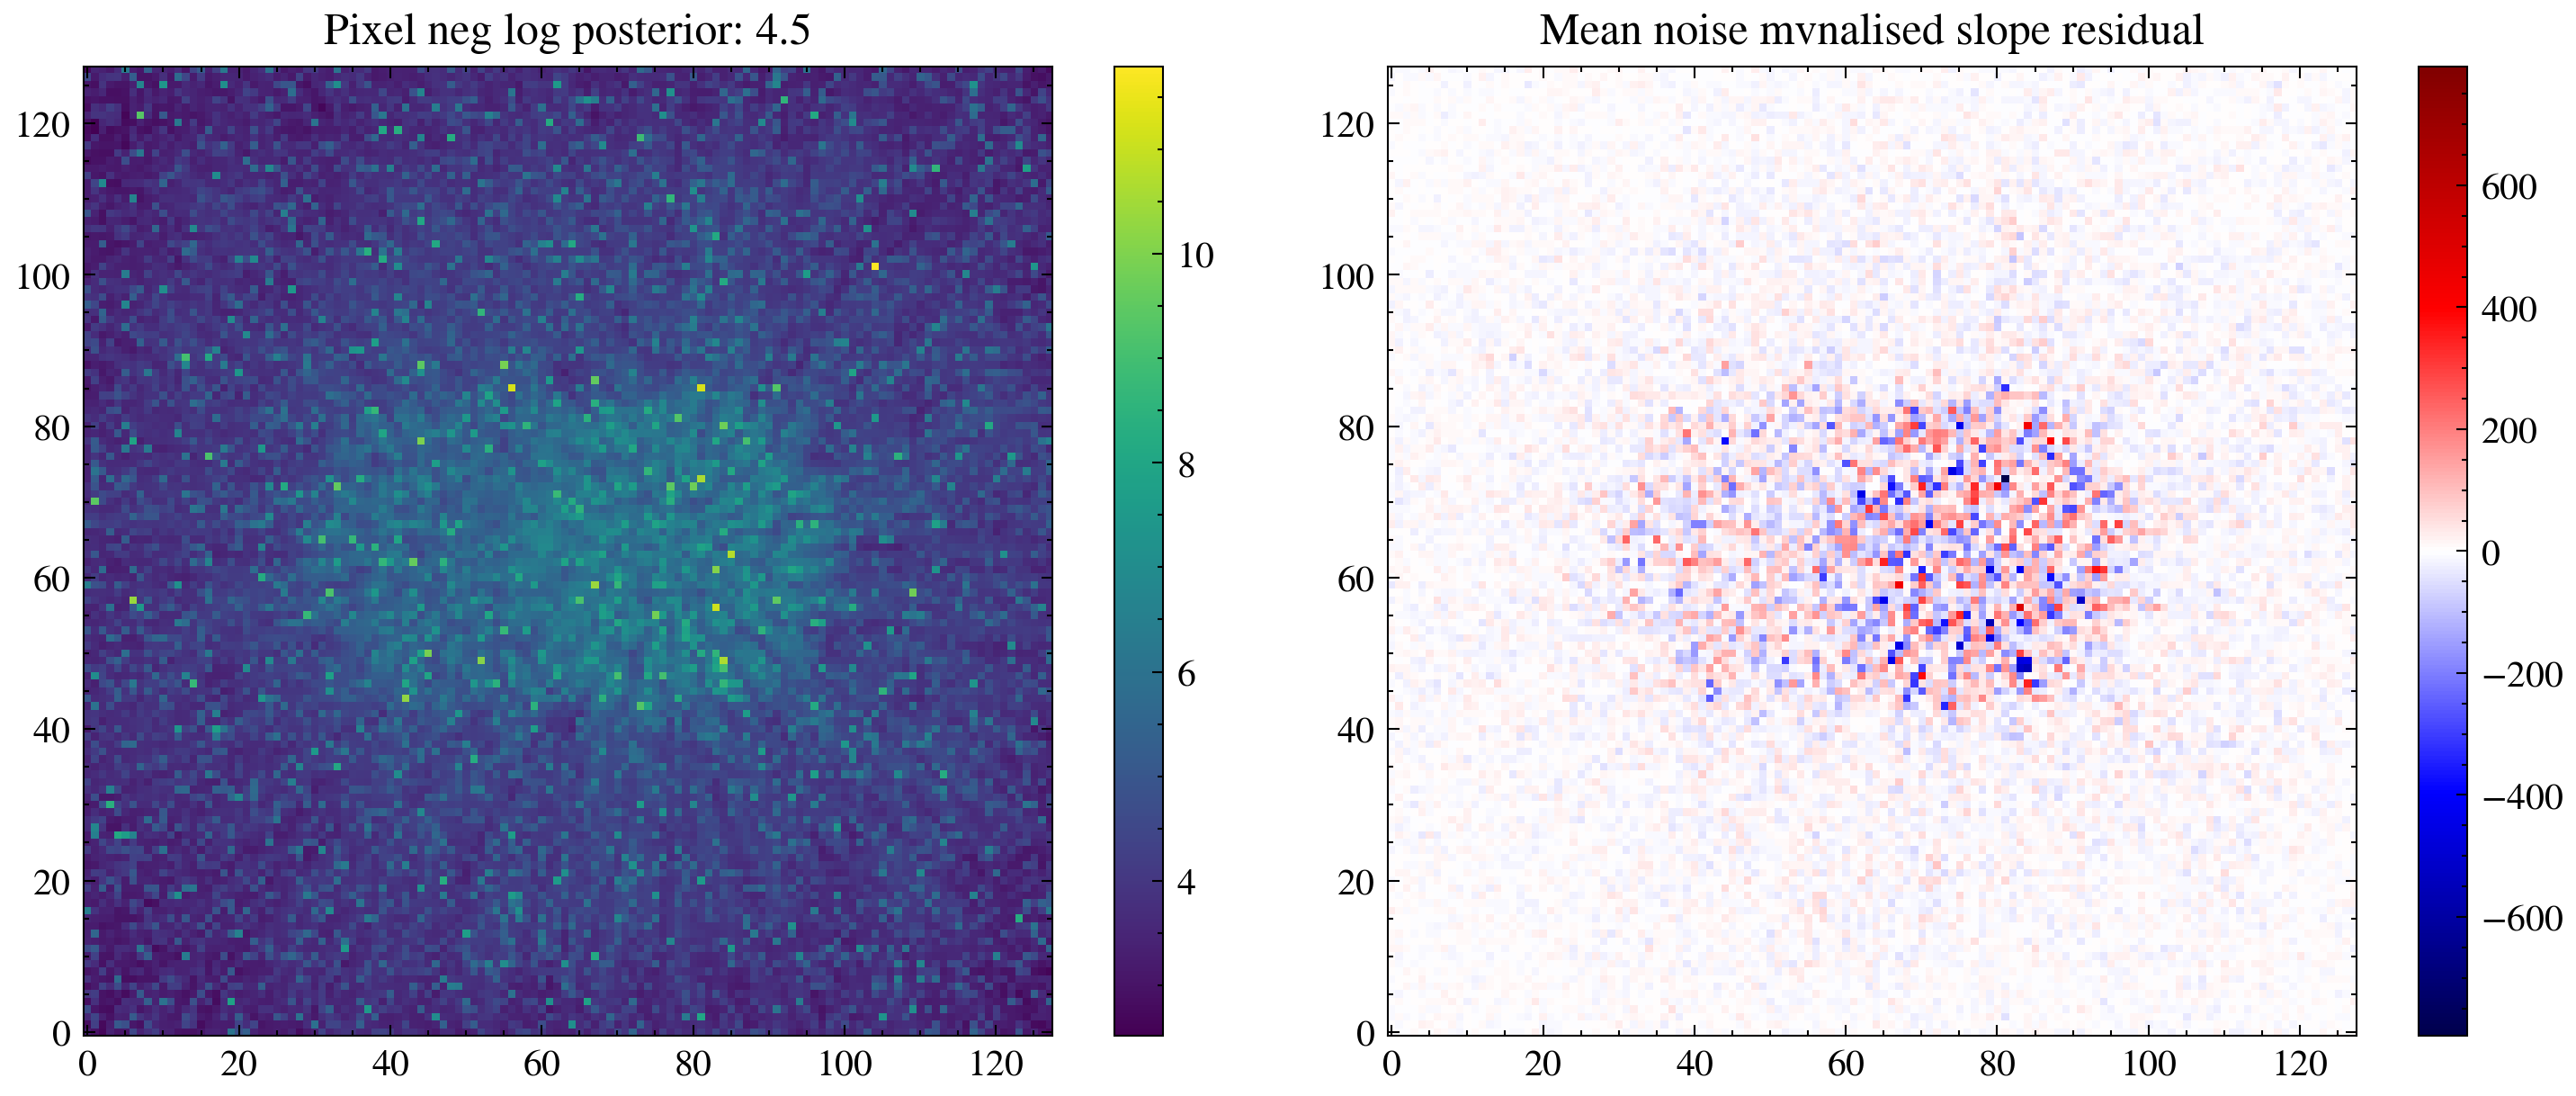

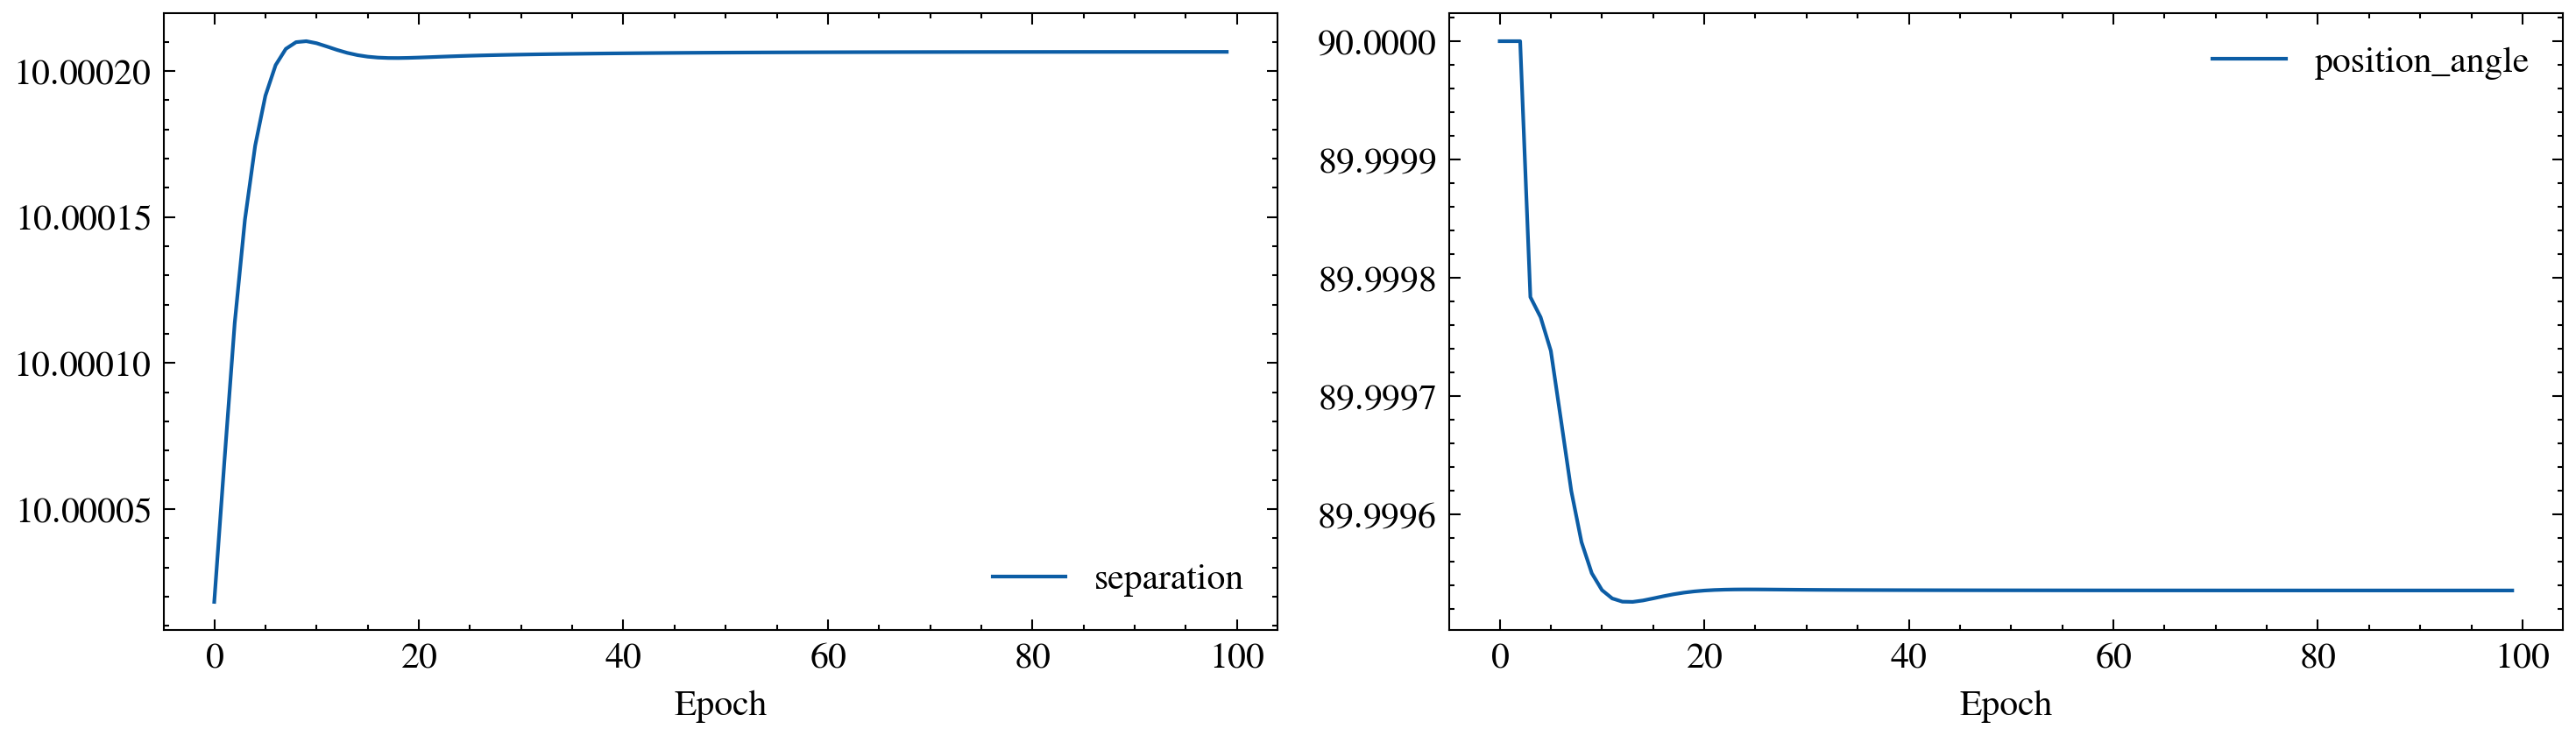

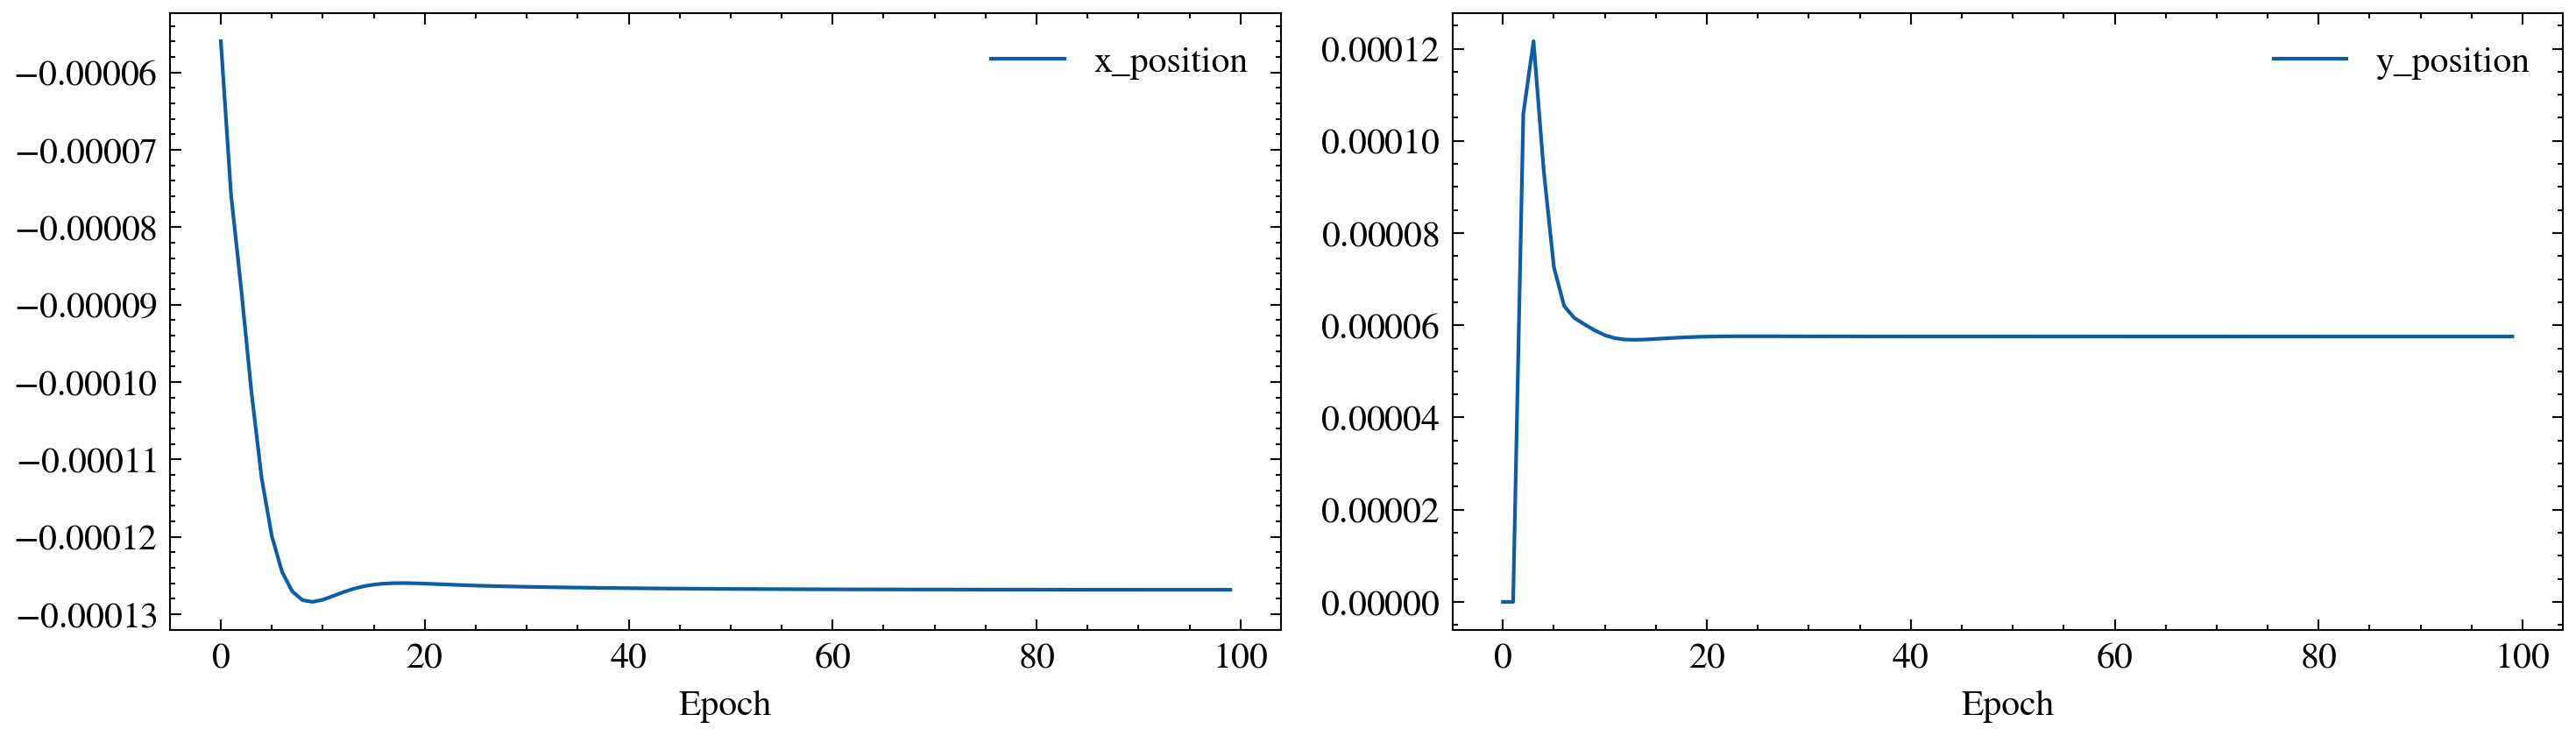

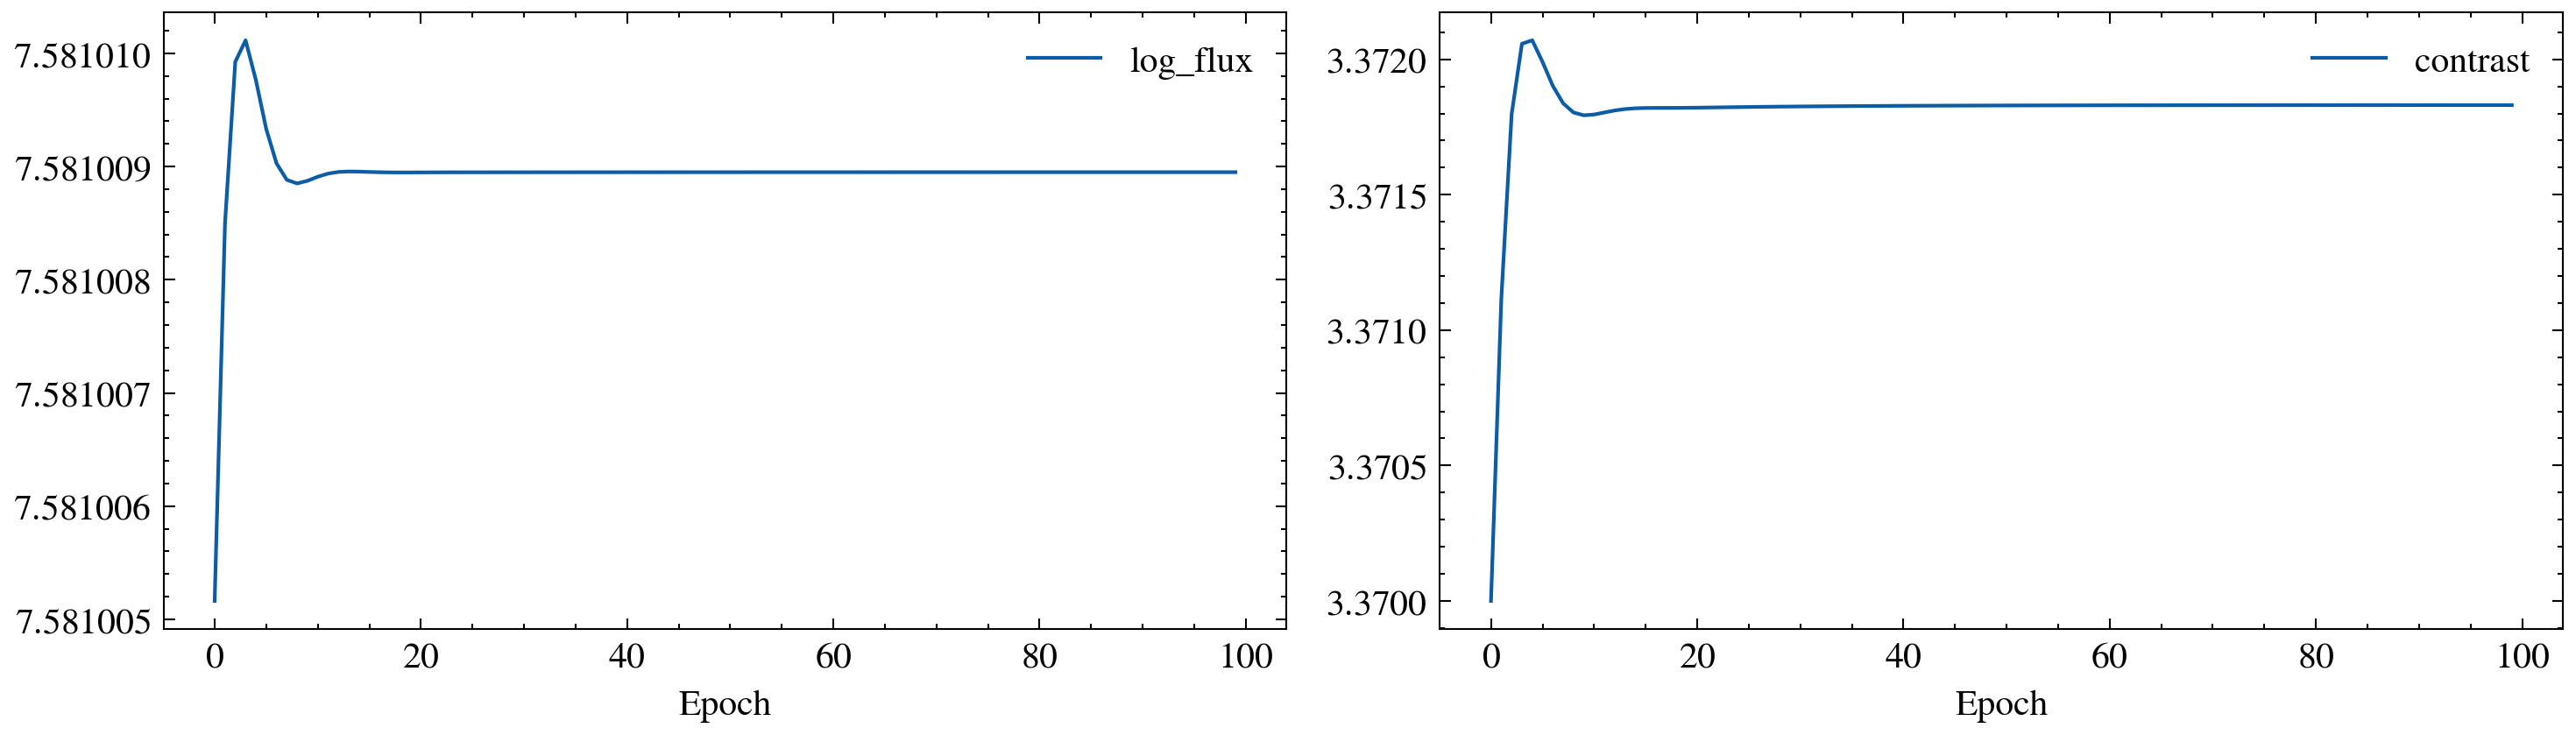

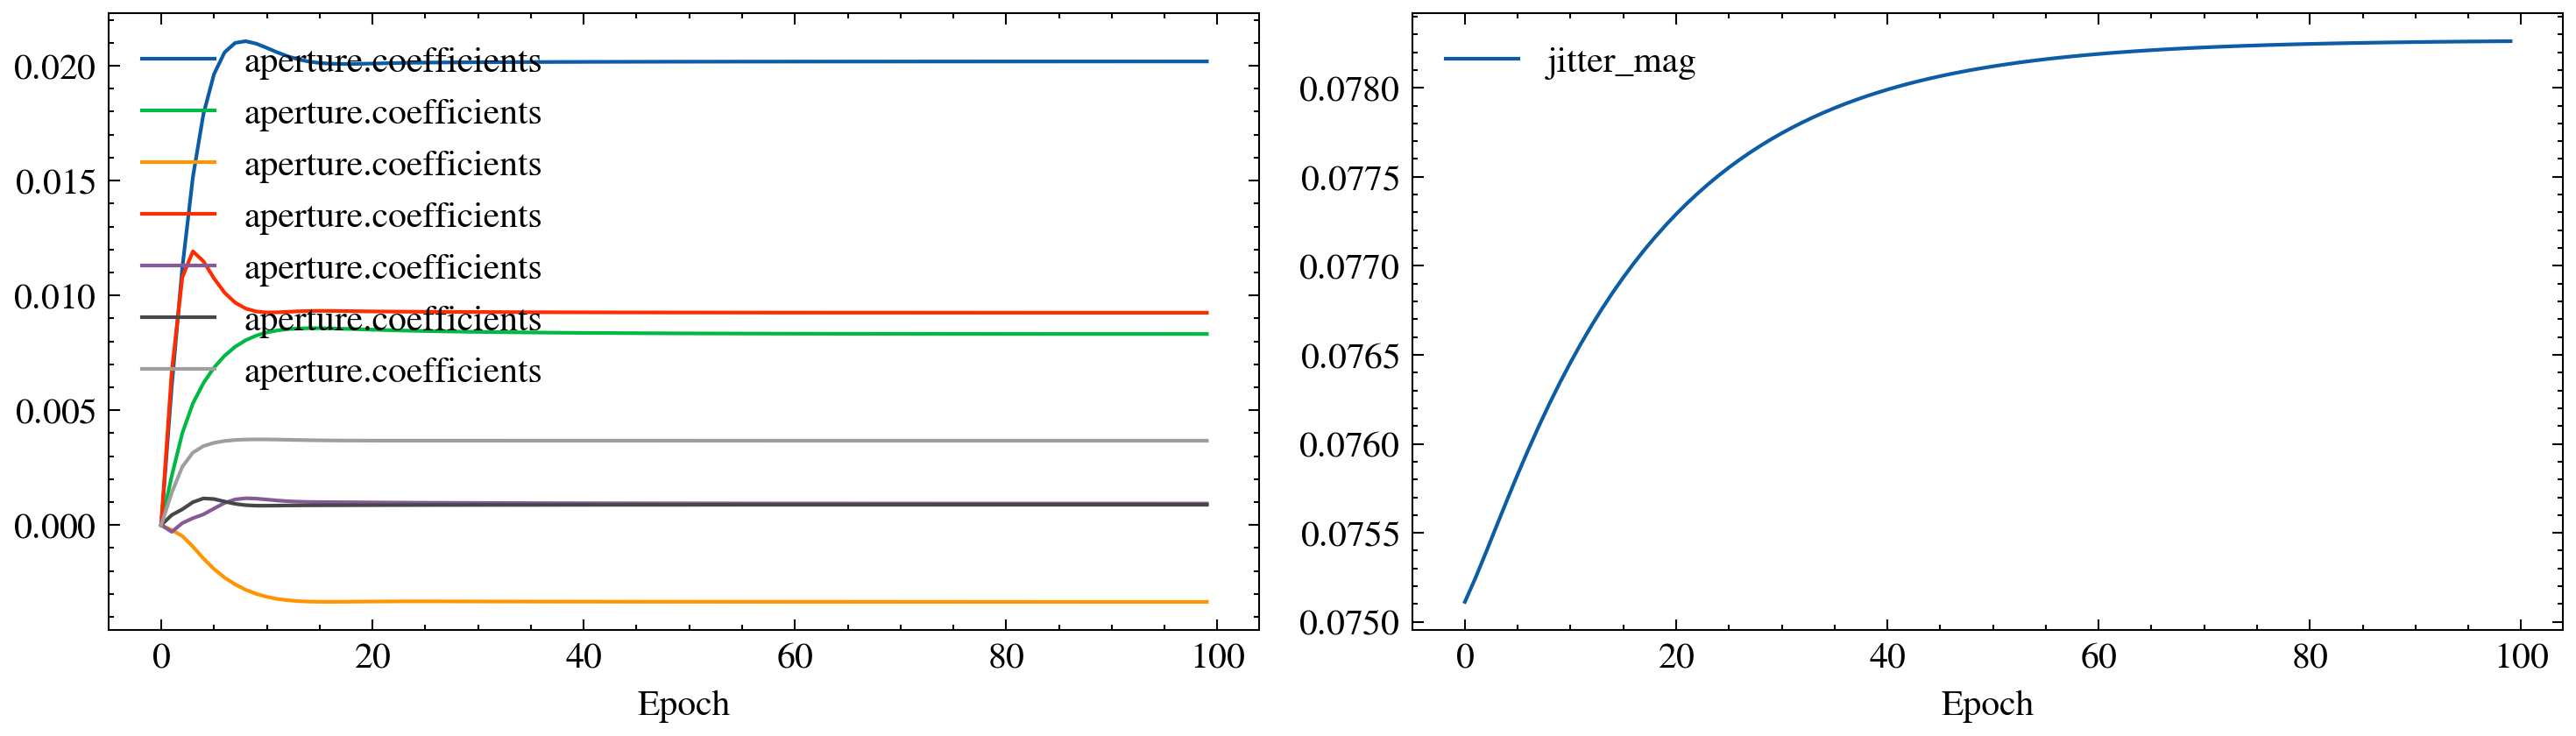

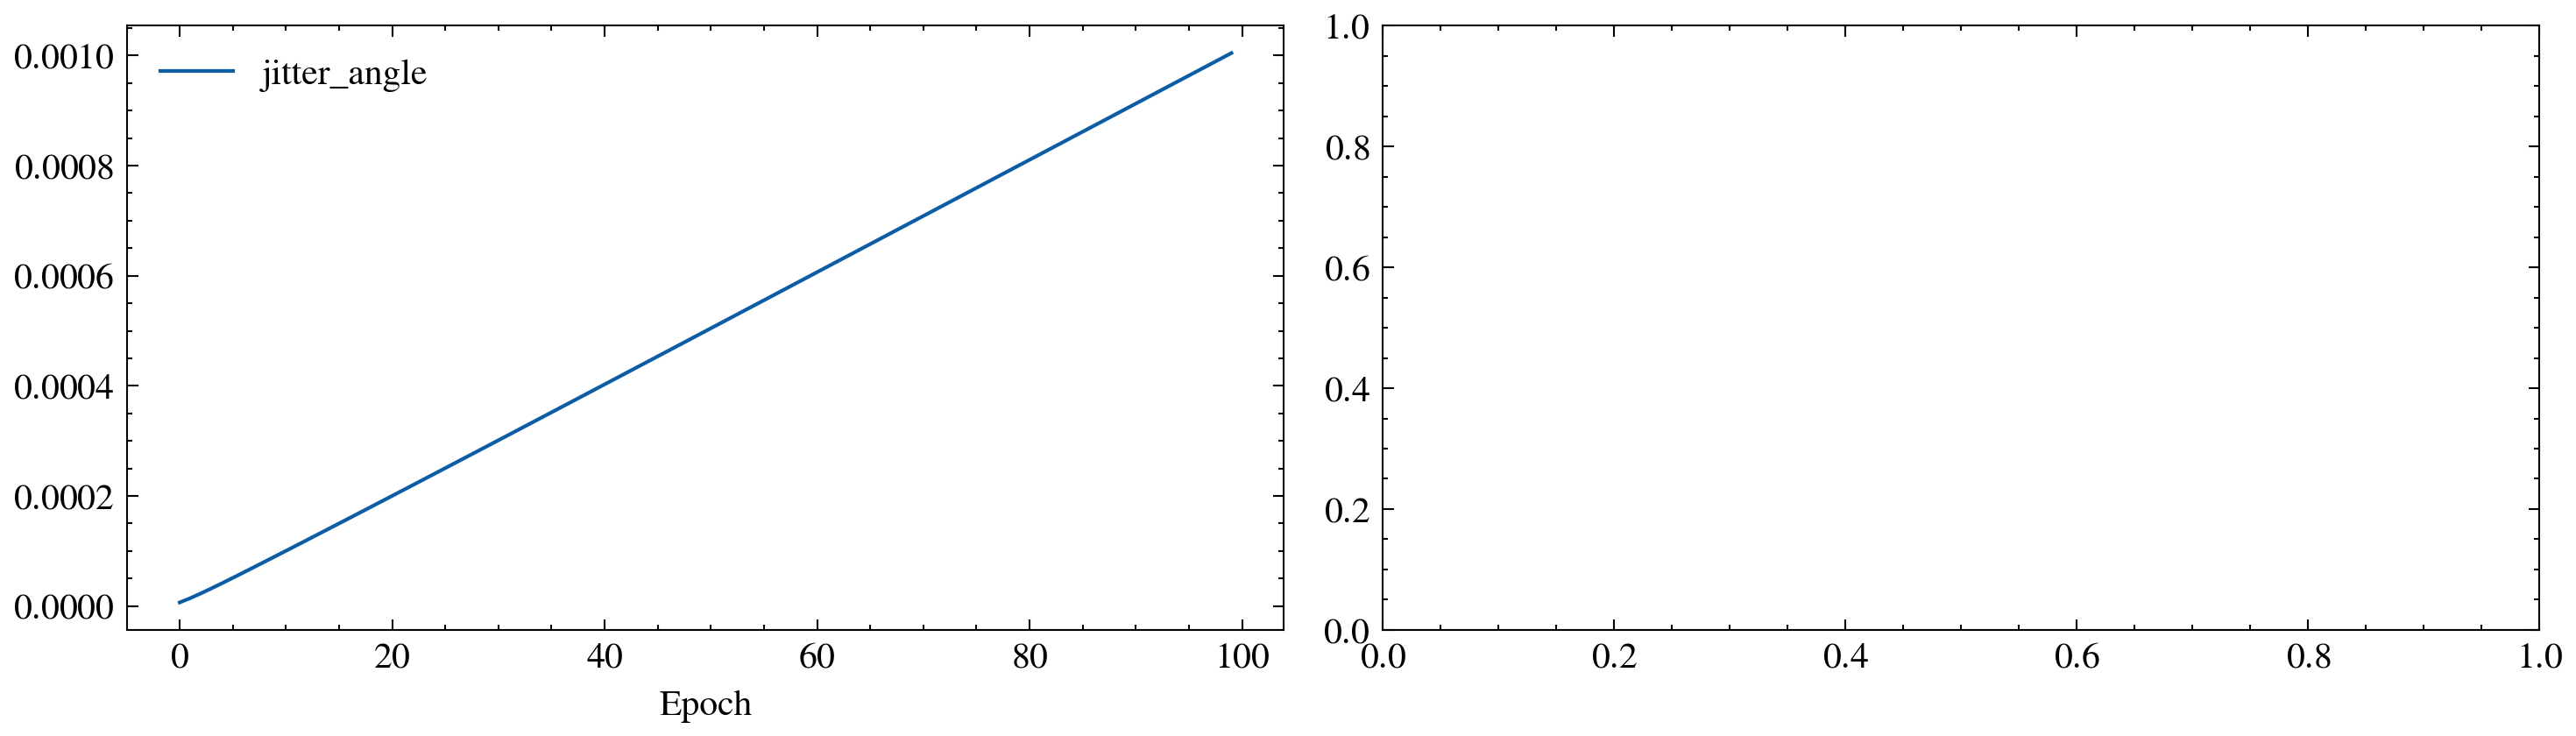

lin lin Realisation 2/5 ['jitter_mag', 'jitter_angle'] [Array(0.15, dtype=float64), Array(0., dtype=float64)]


Gradient Descent:   0%|          | 0/100 [00:00<?, ?it/s]

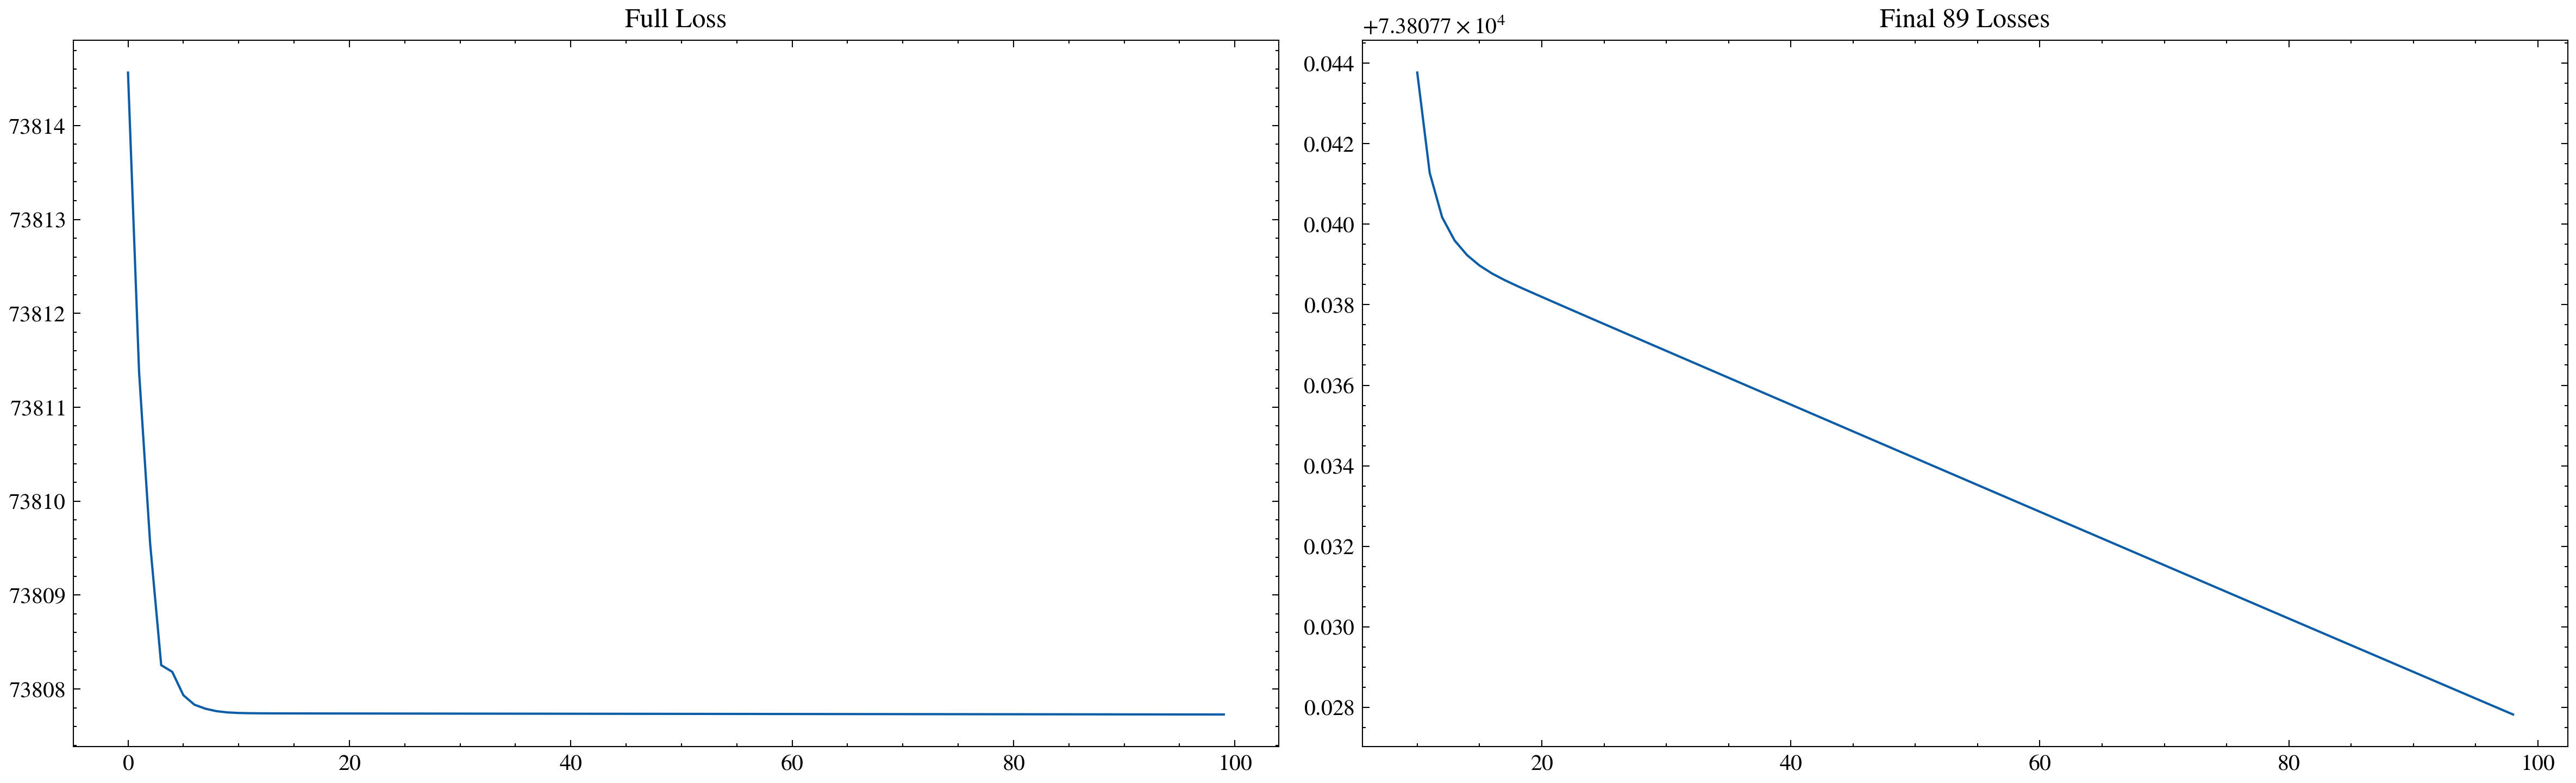

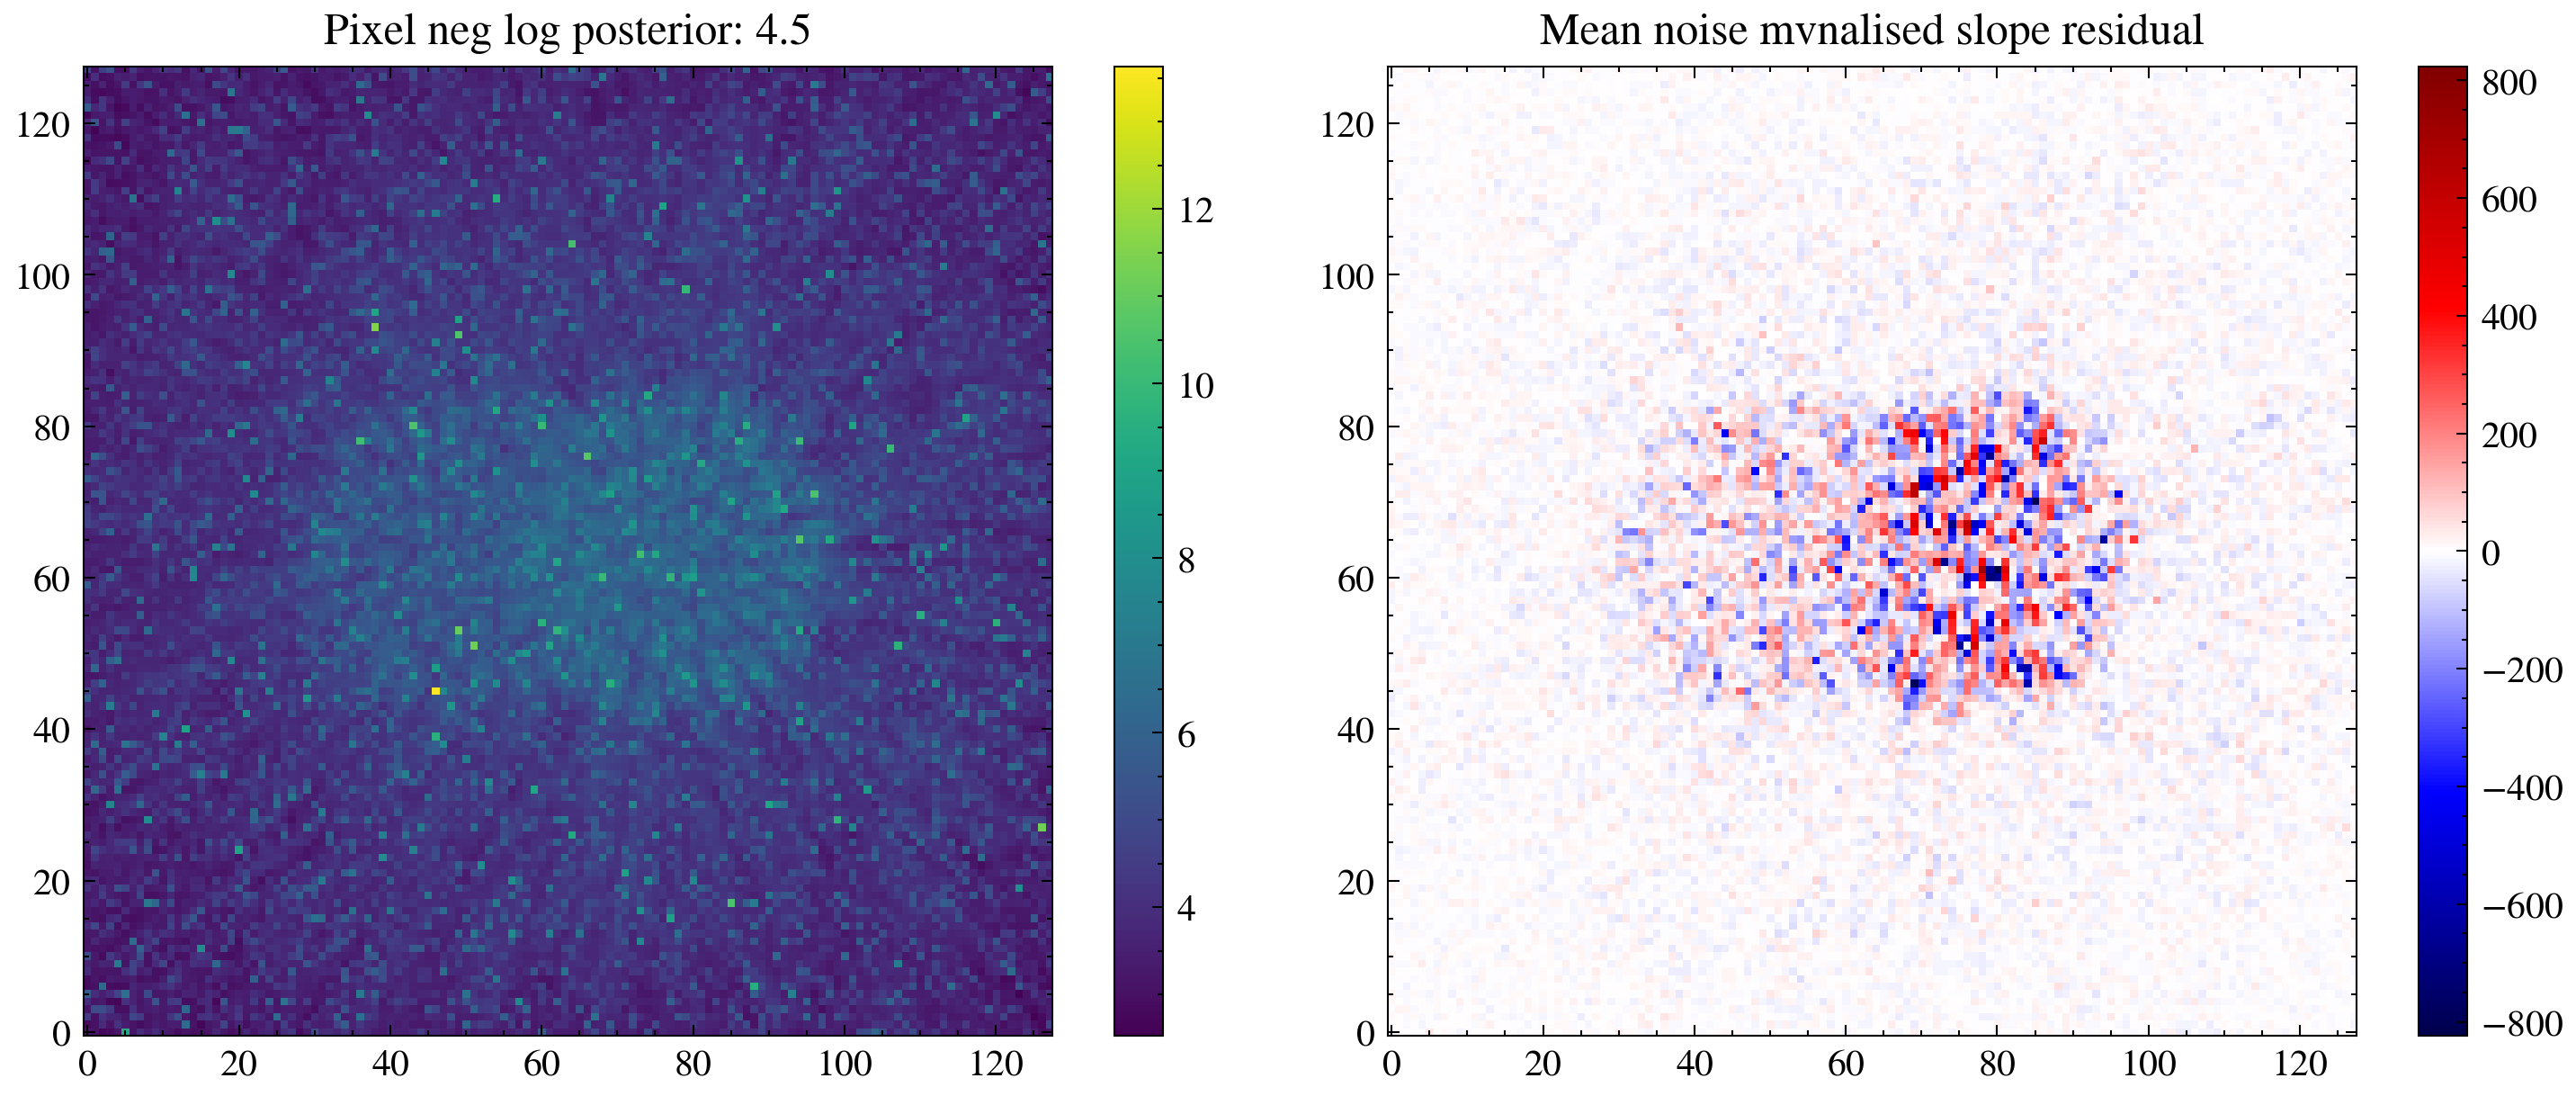

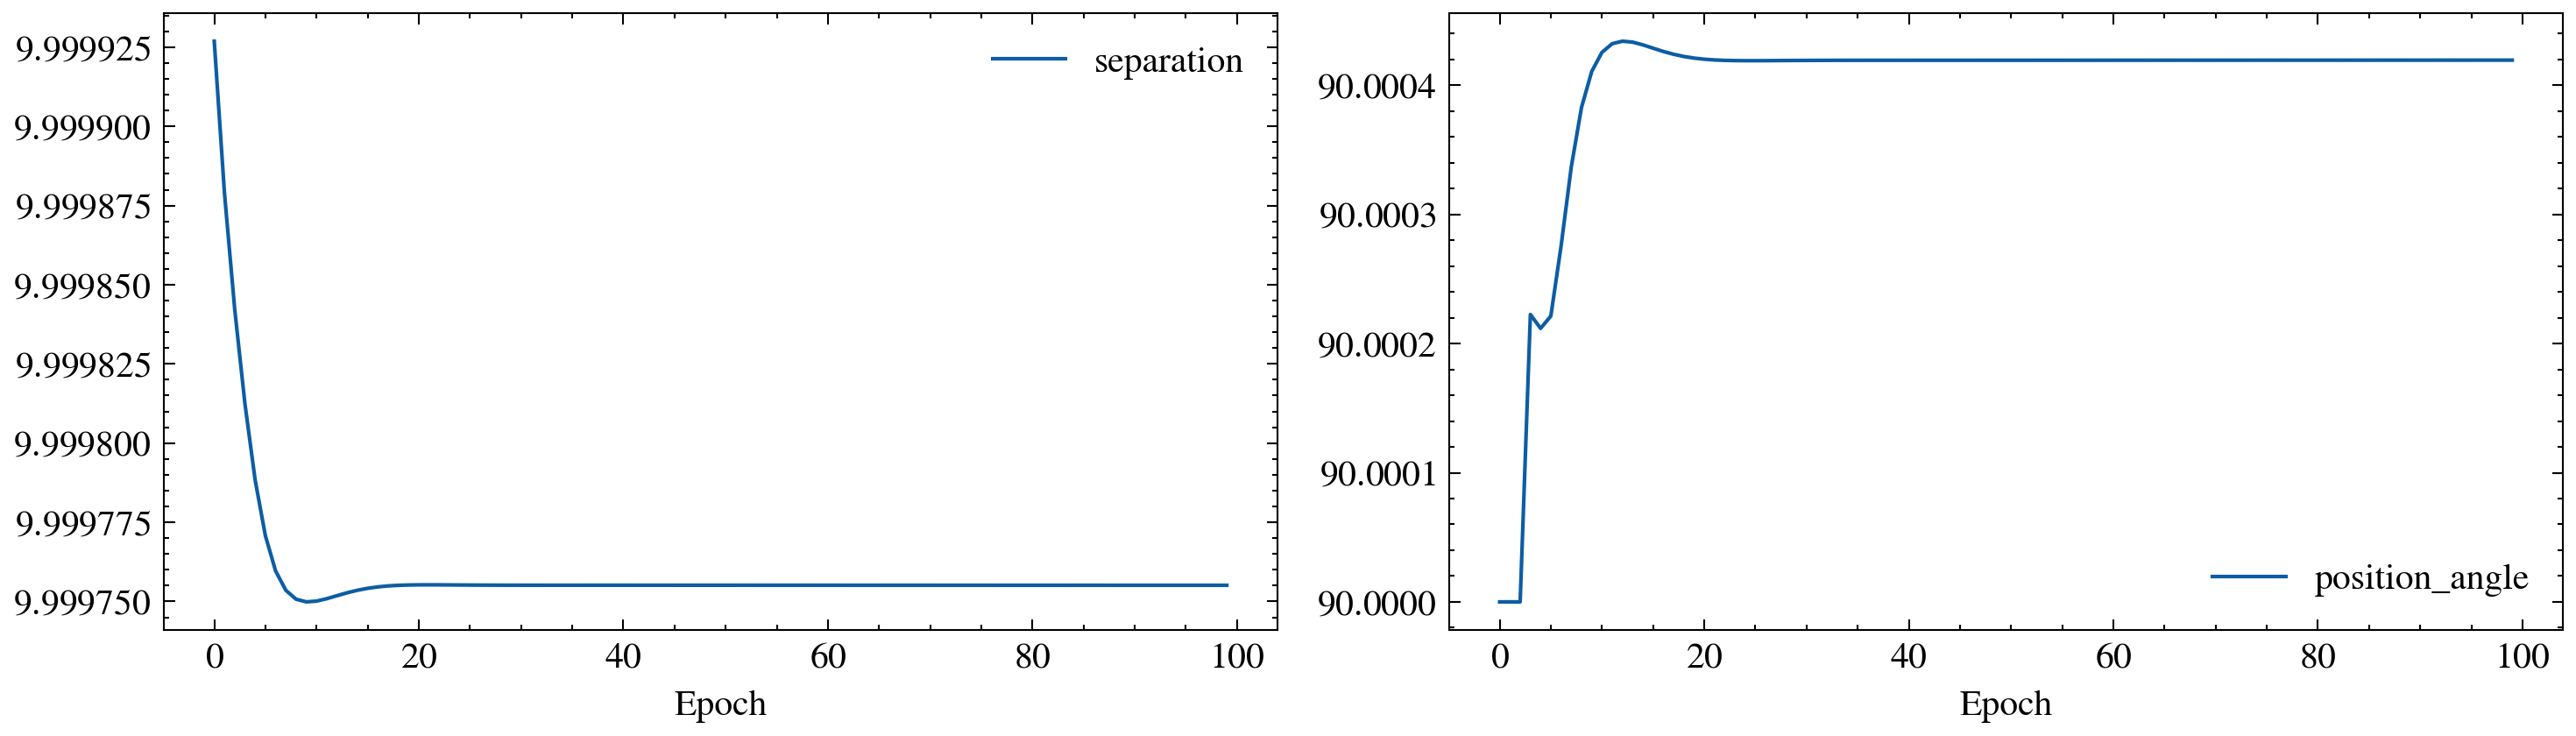

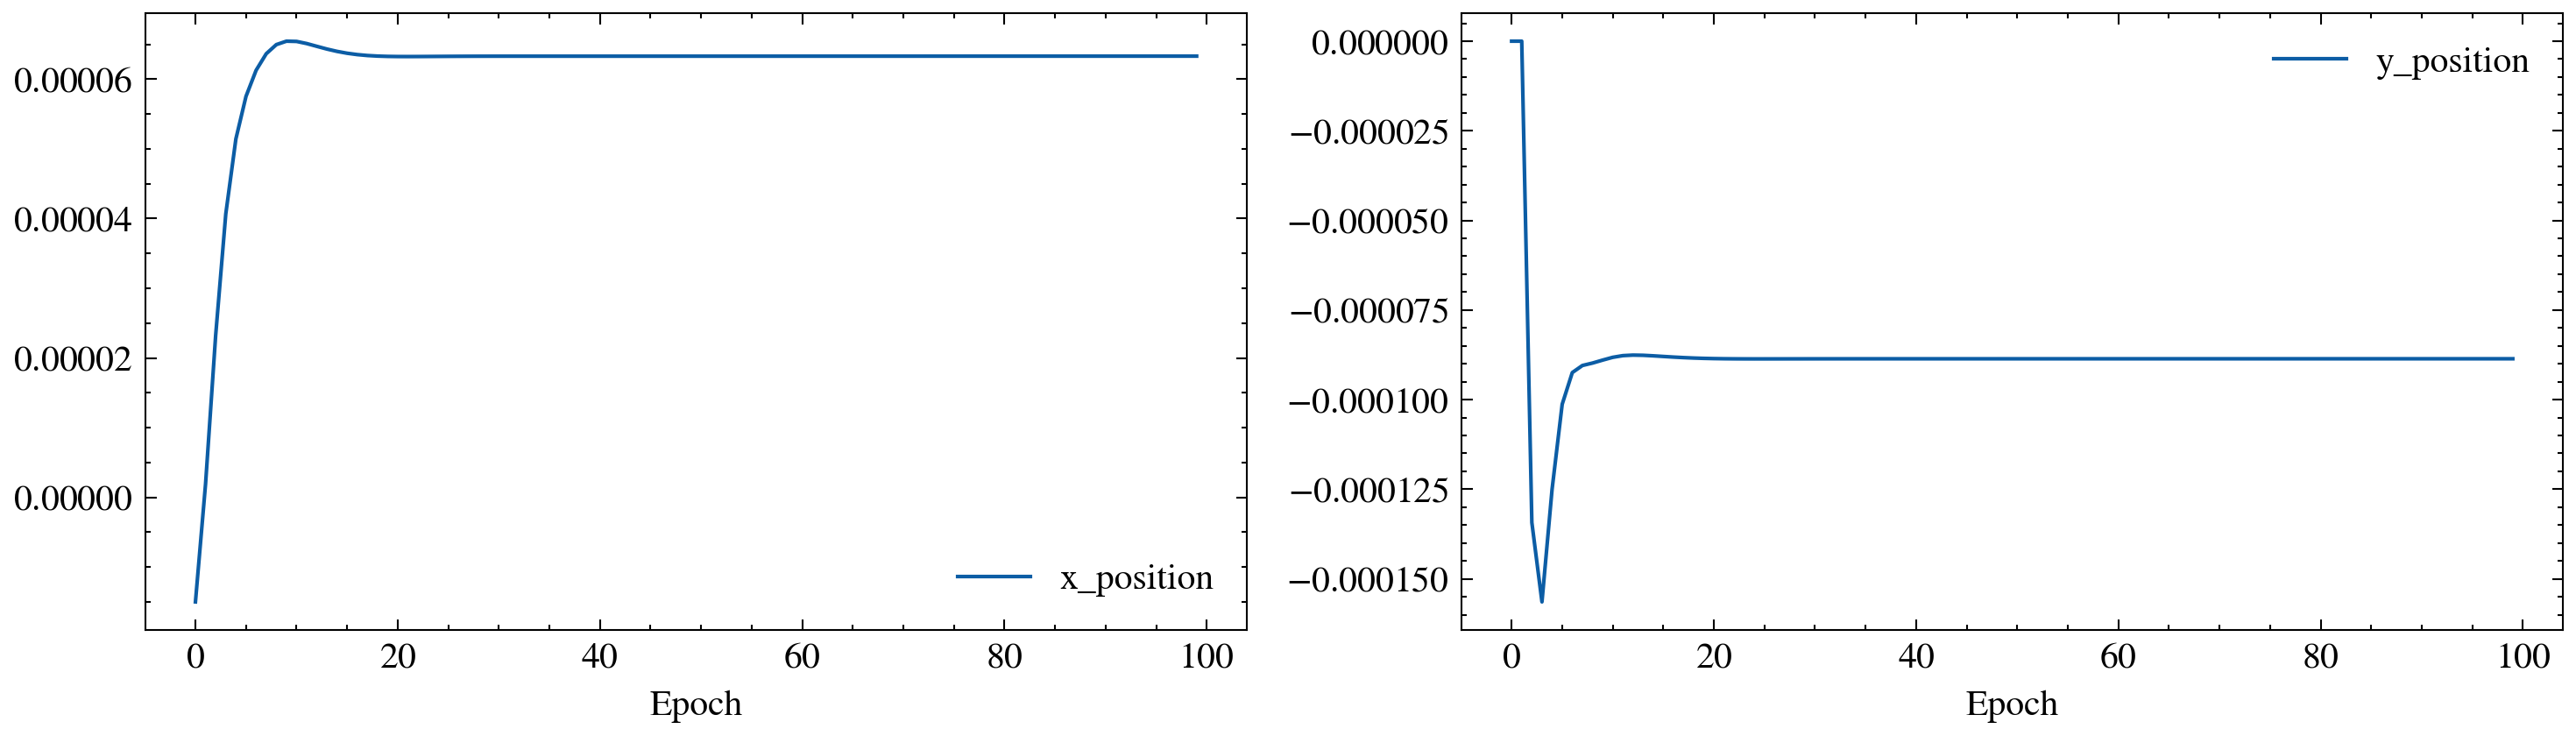

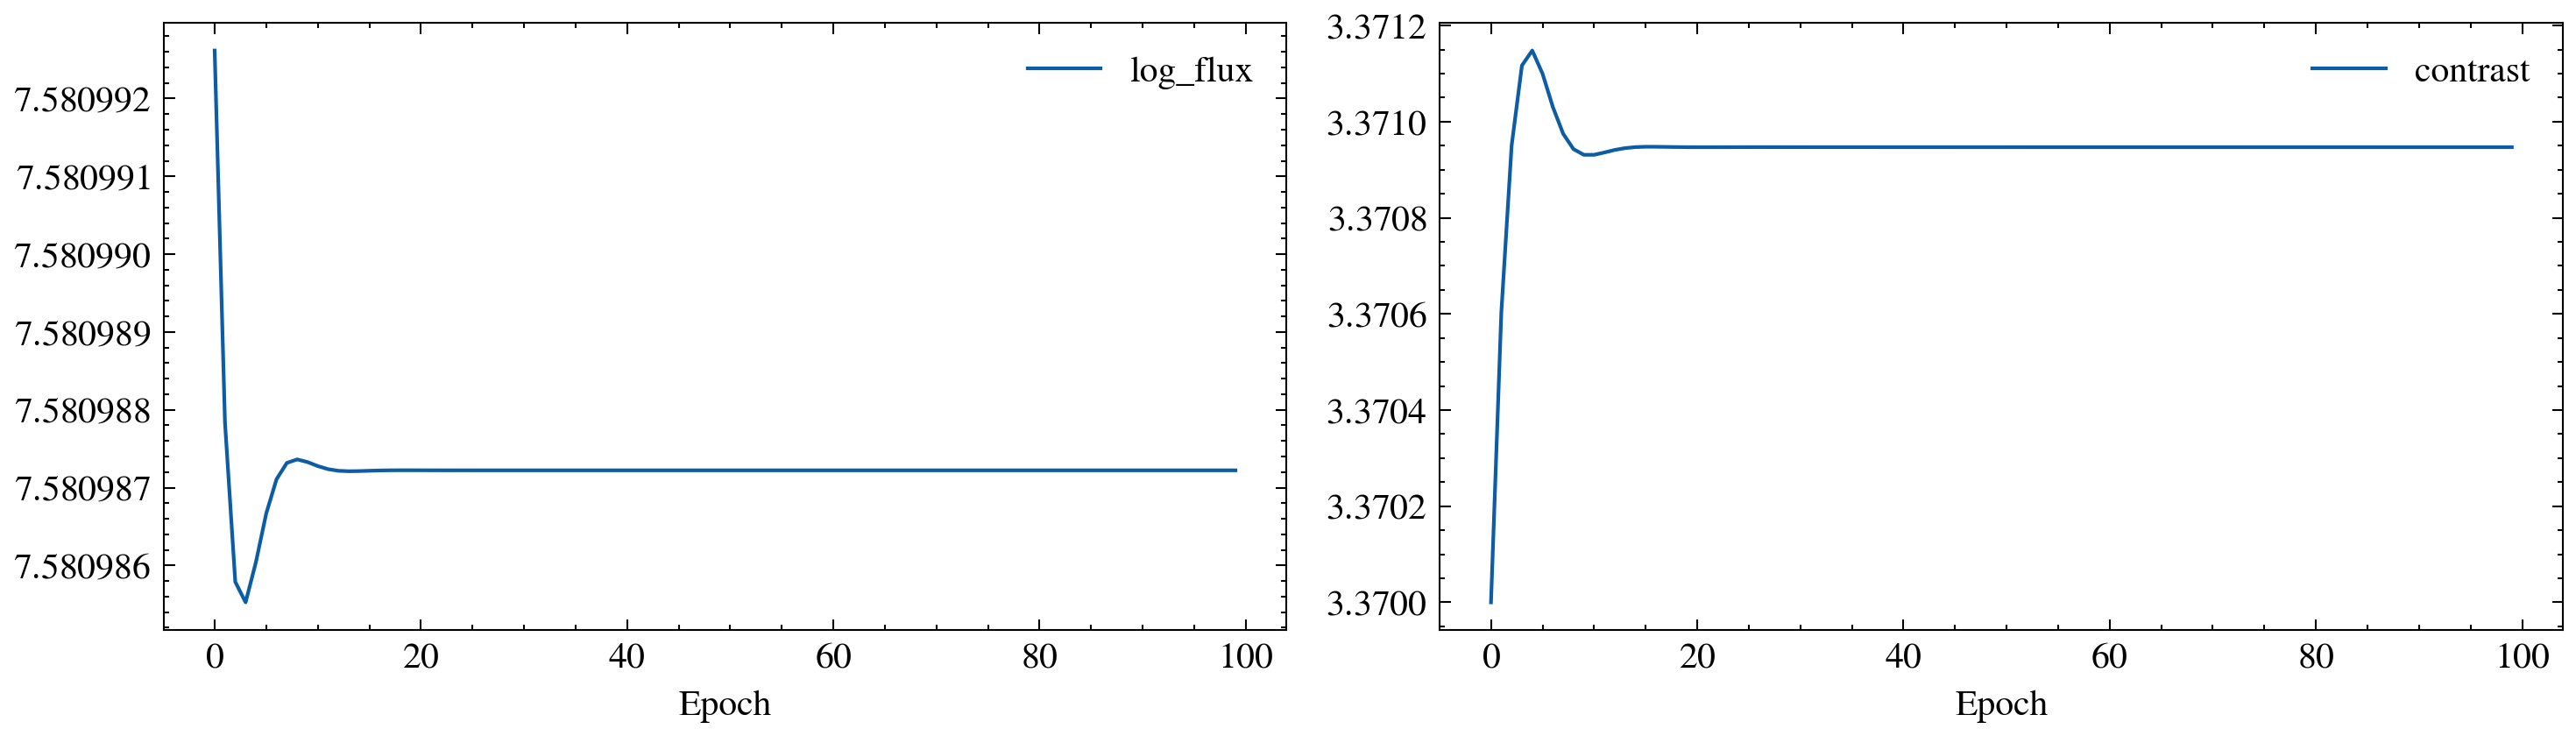

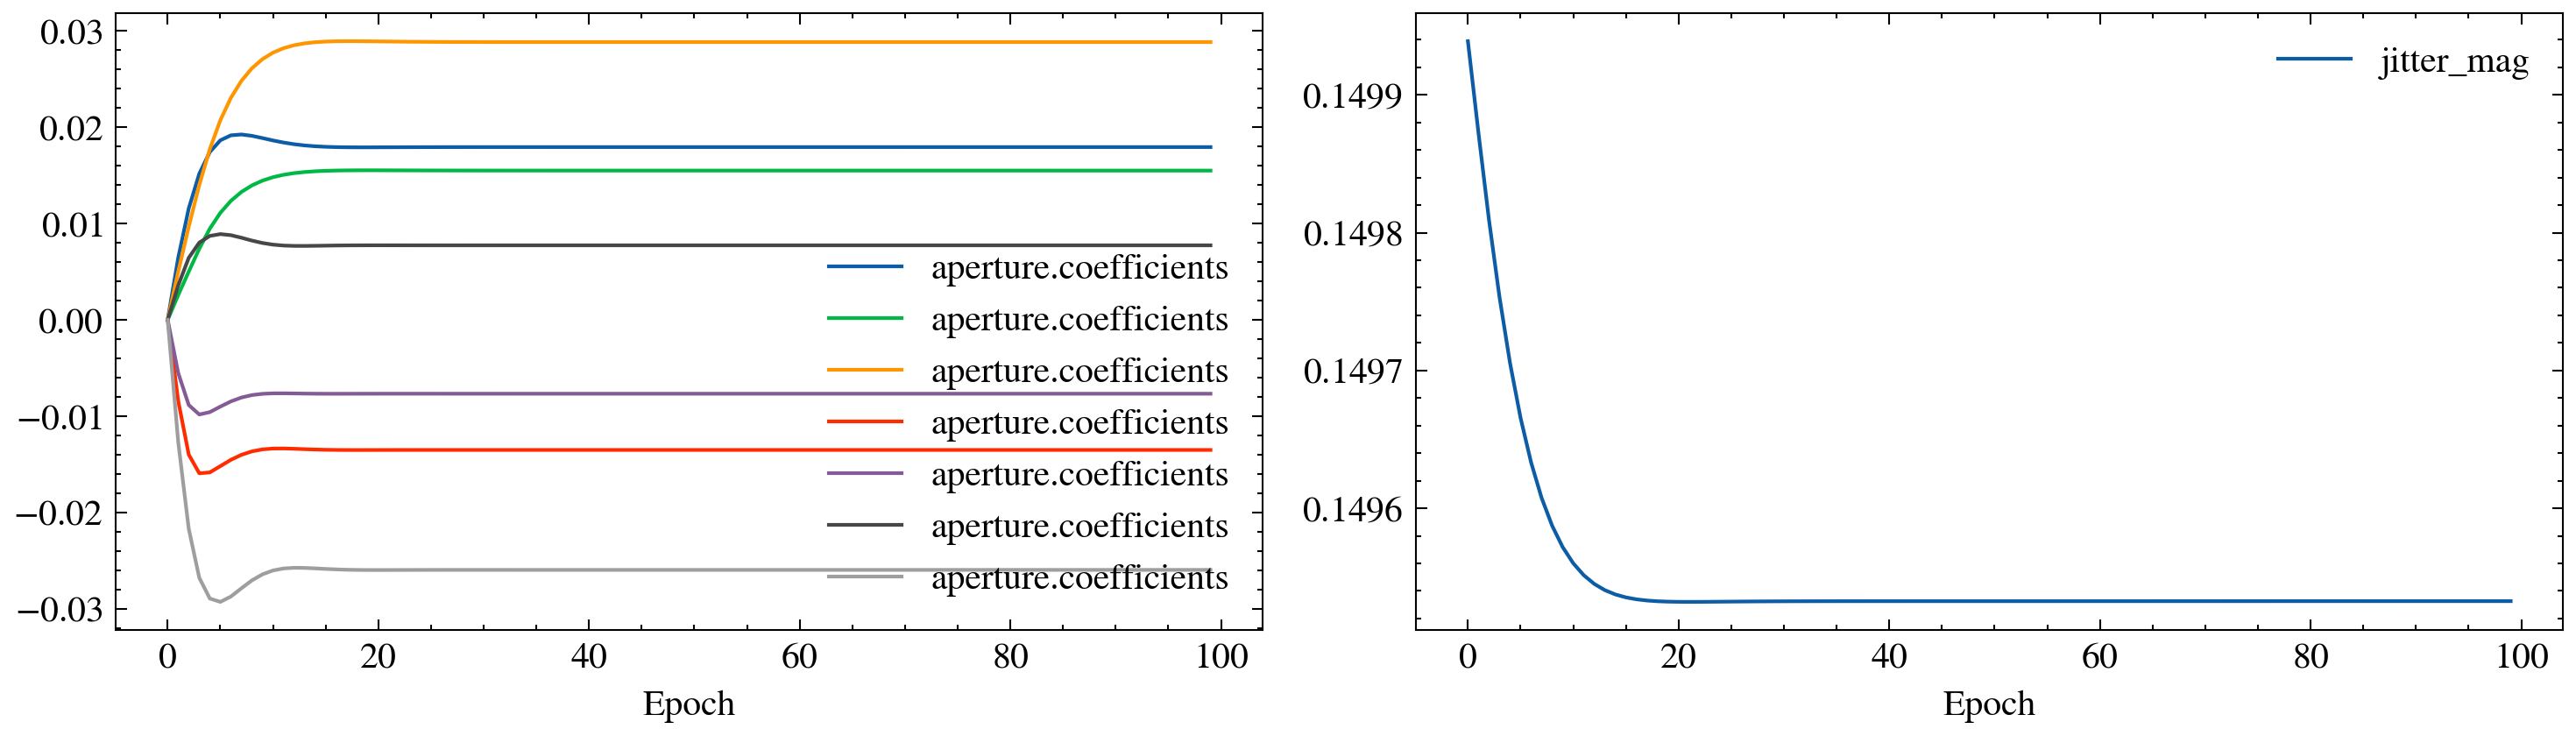

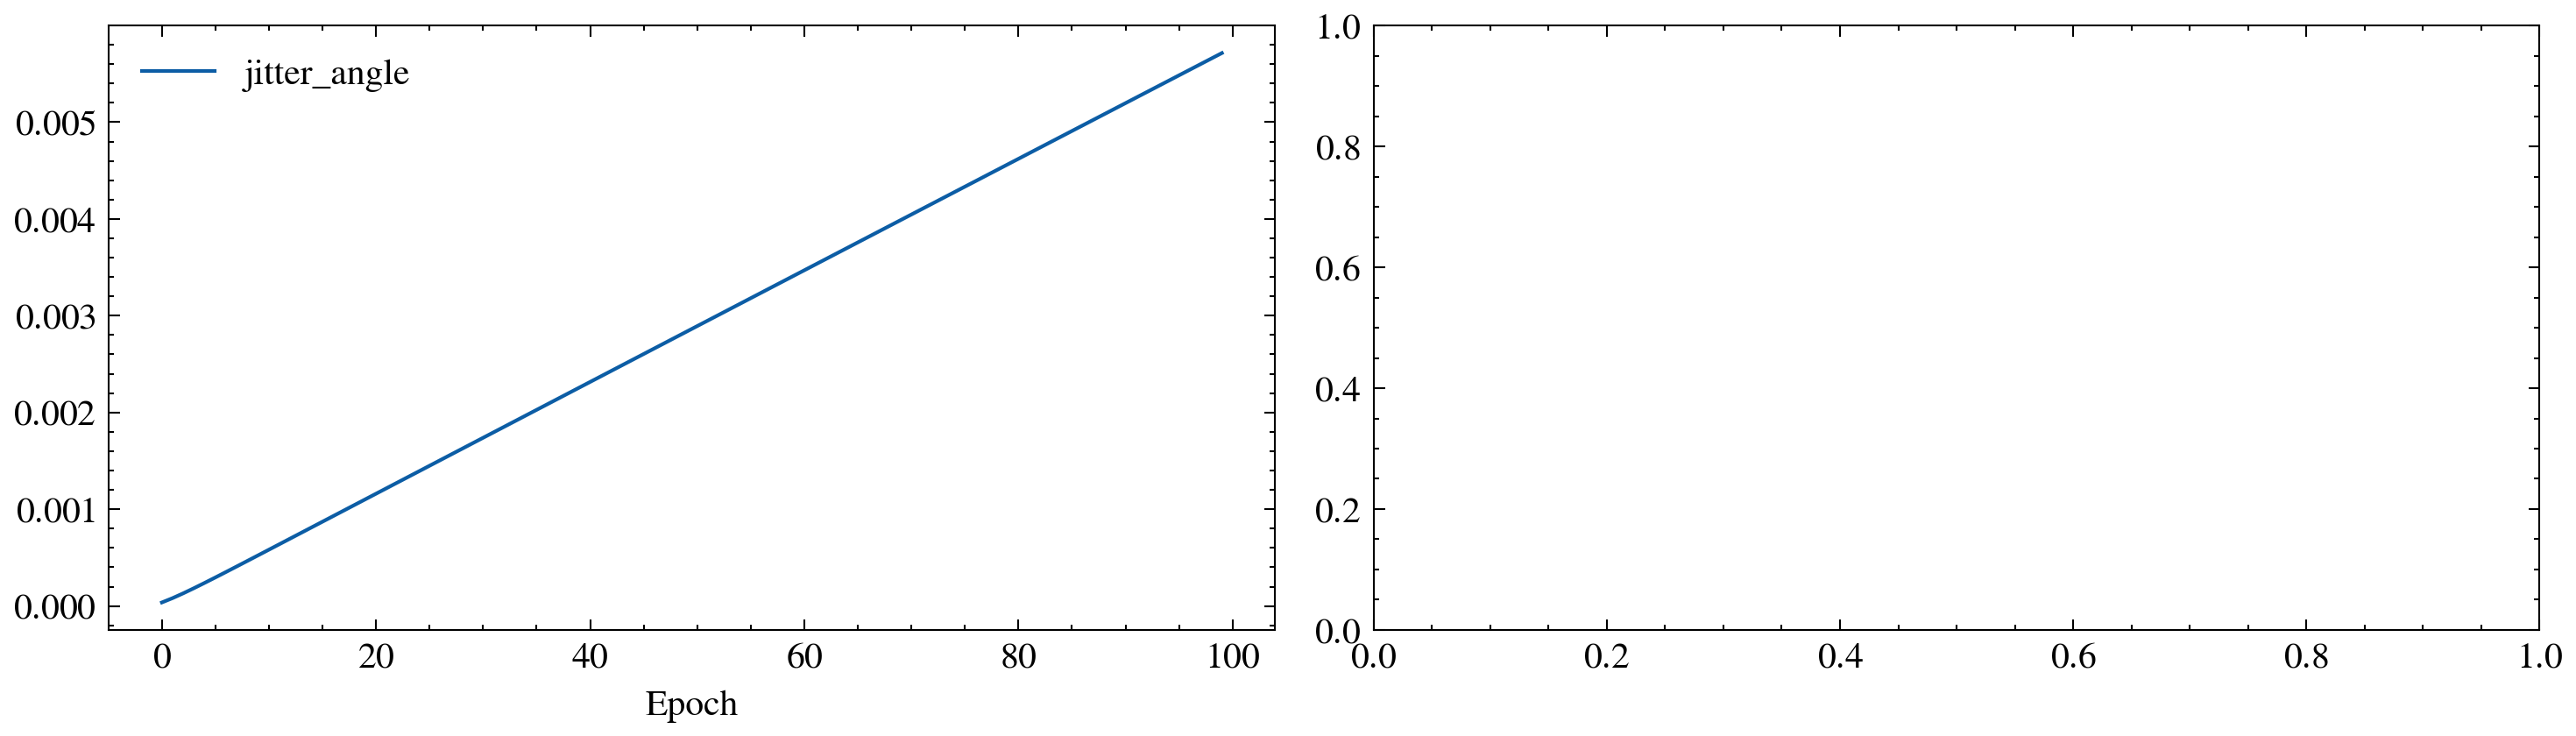

lin lin Realisation 3/5 ['jitter_mag', 'jitter_angle'] [Array(0.225, dtype=float64), Array(0., dtype=float64)]


Gradient Descent:   0%|          | 0/100 [00:00<?, ?it/s]

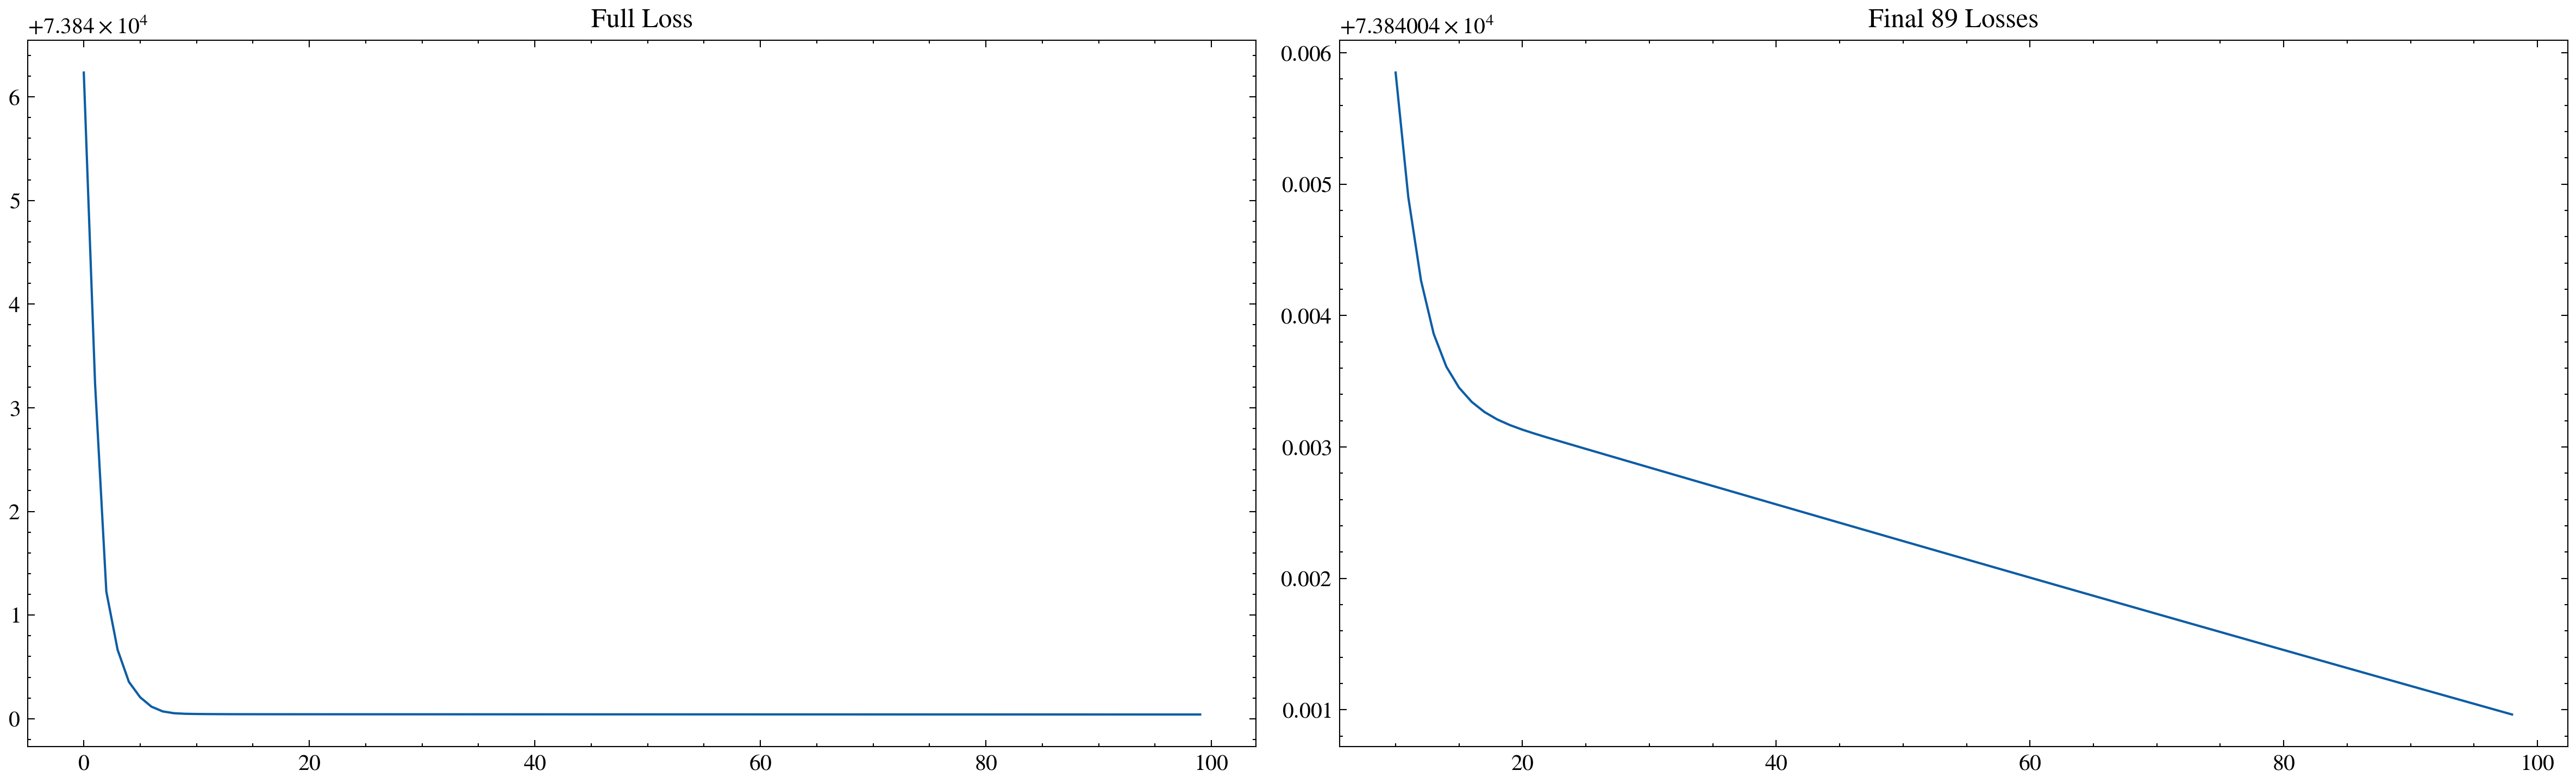

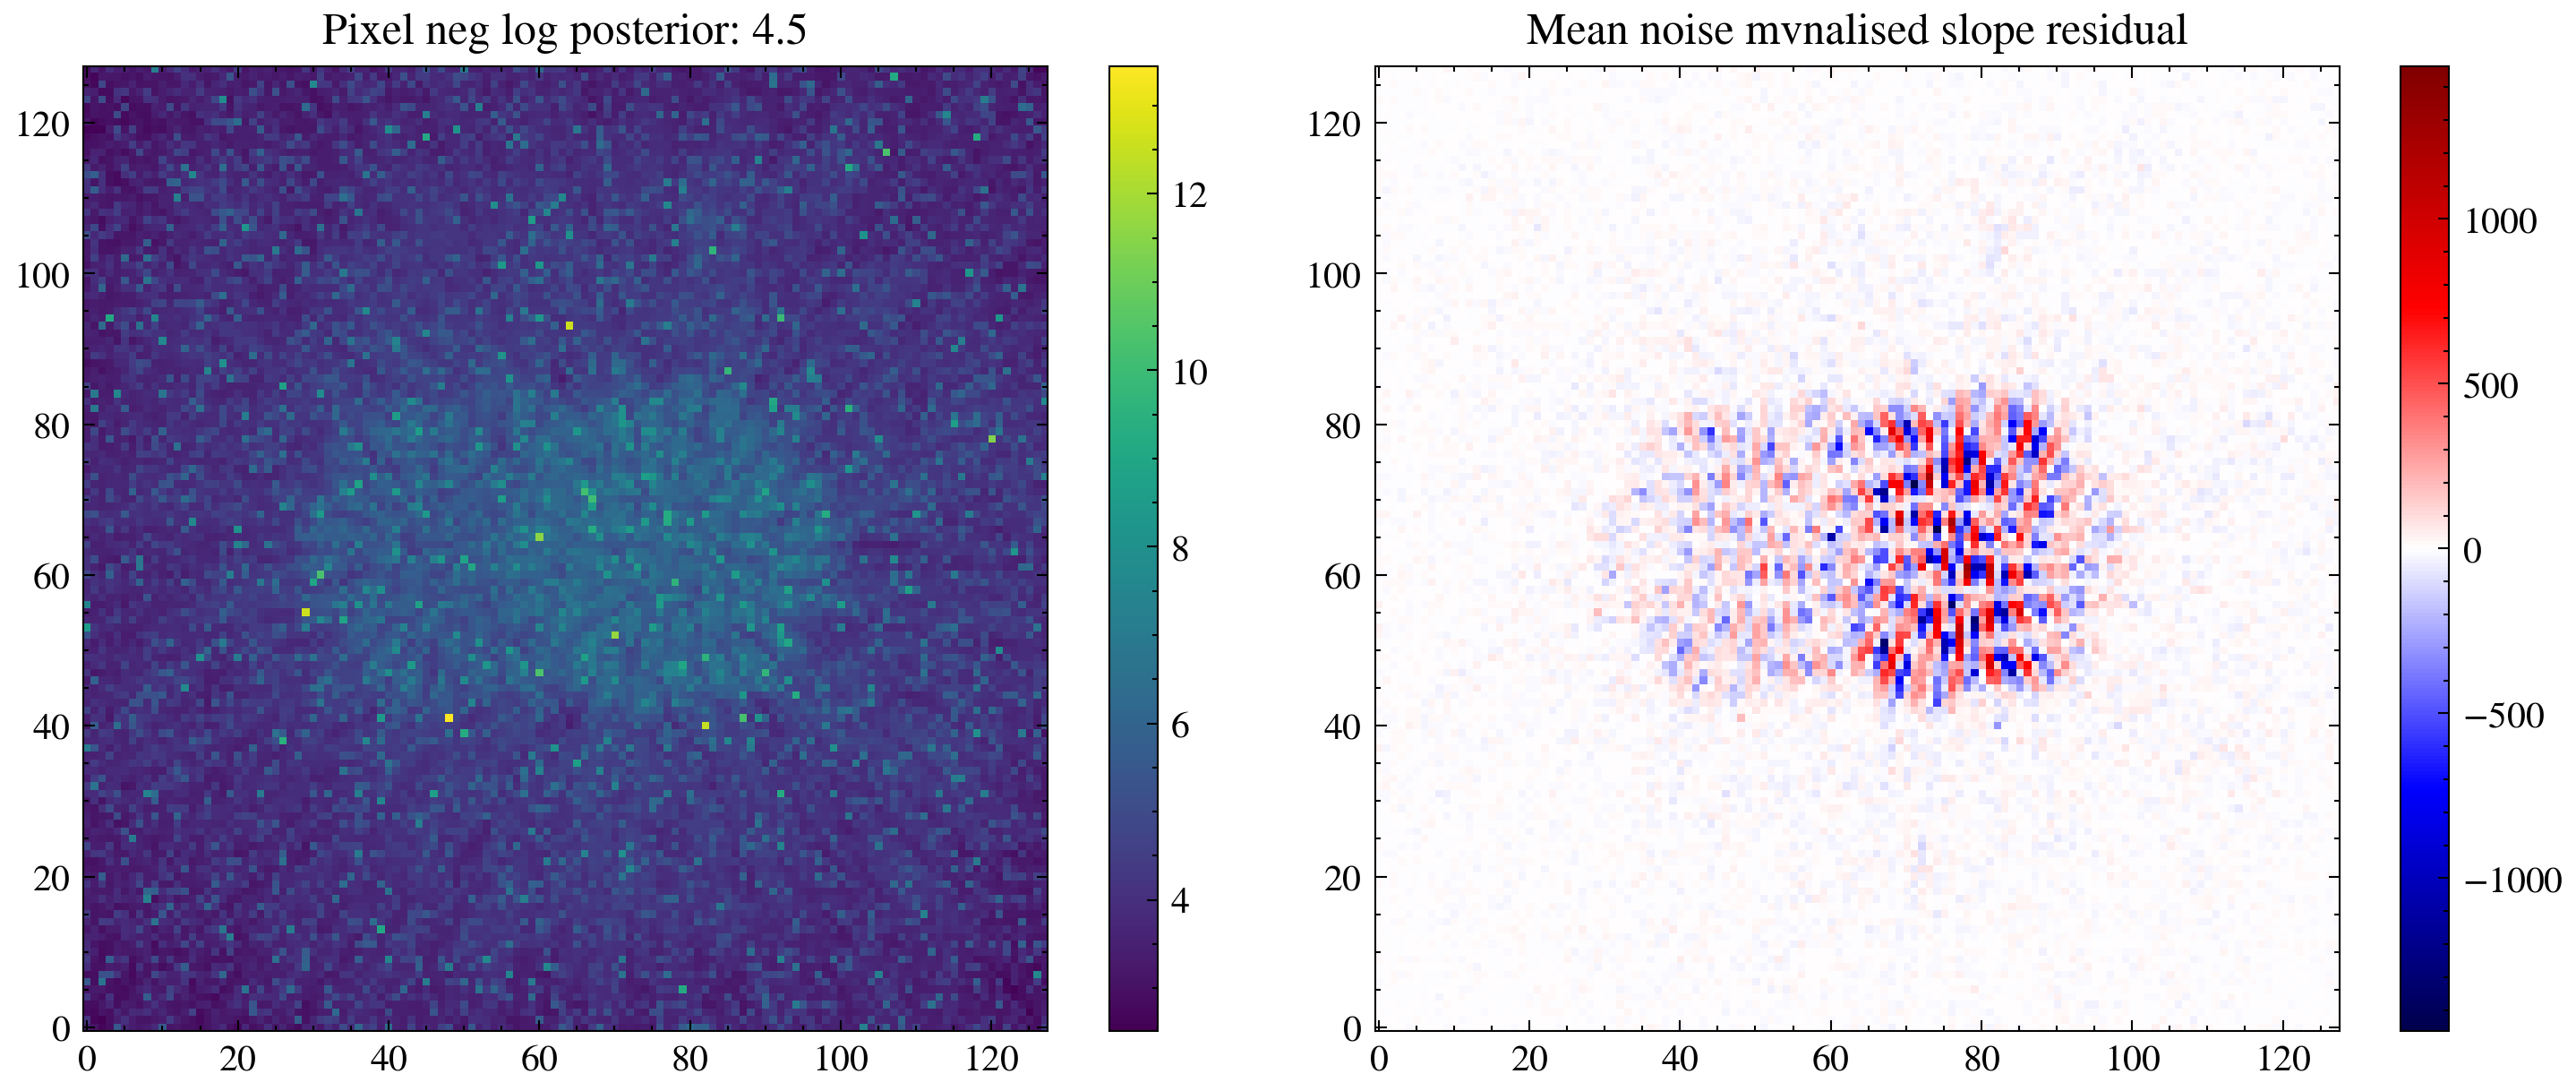

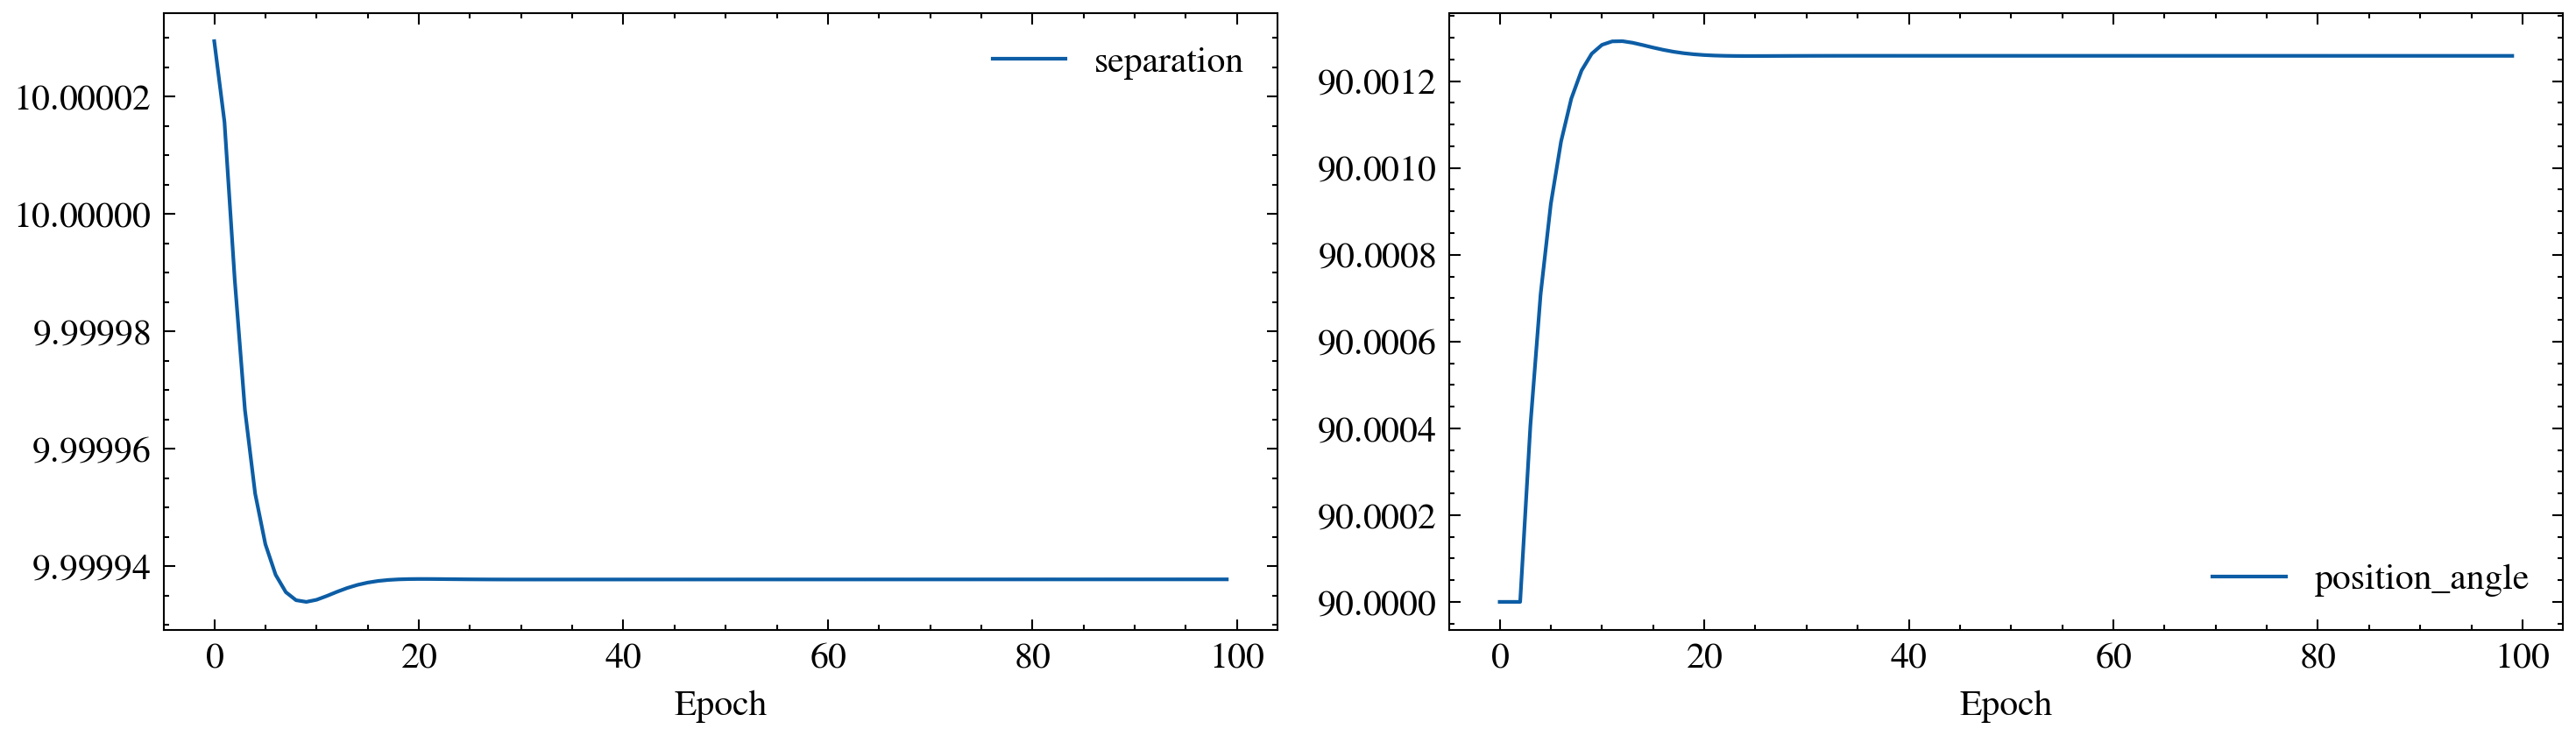

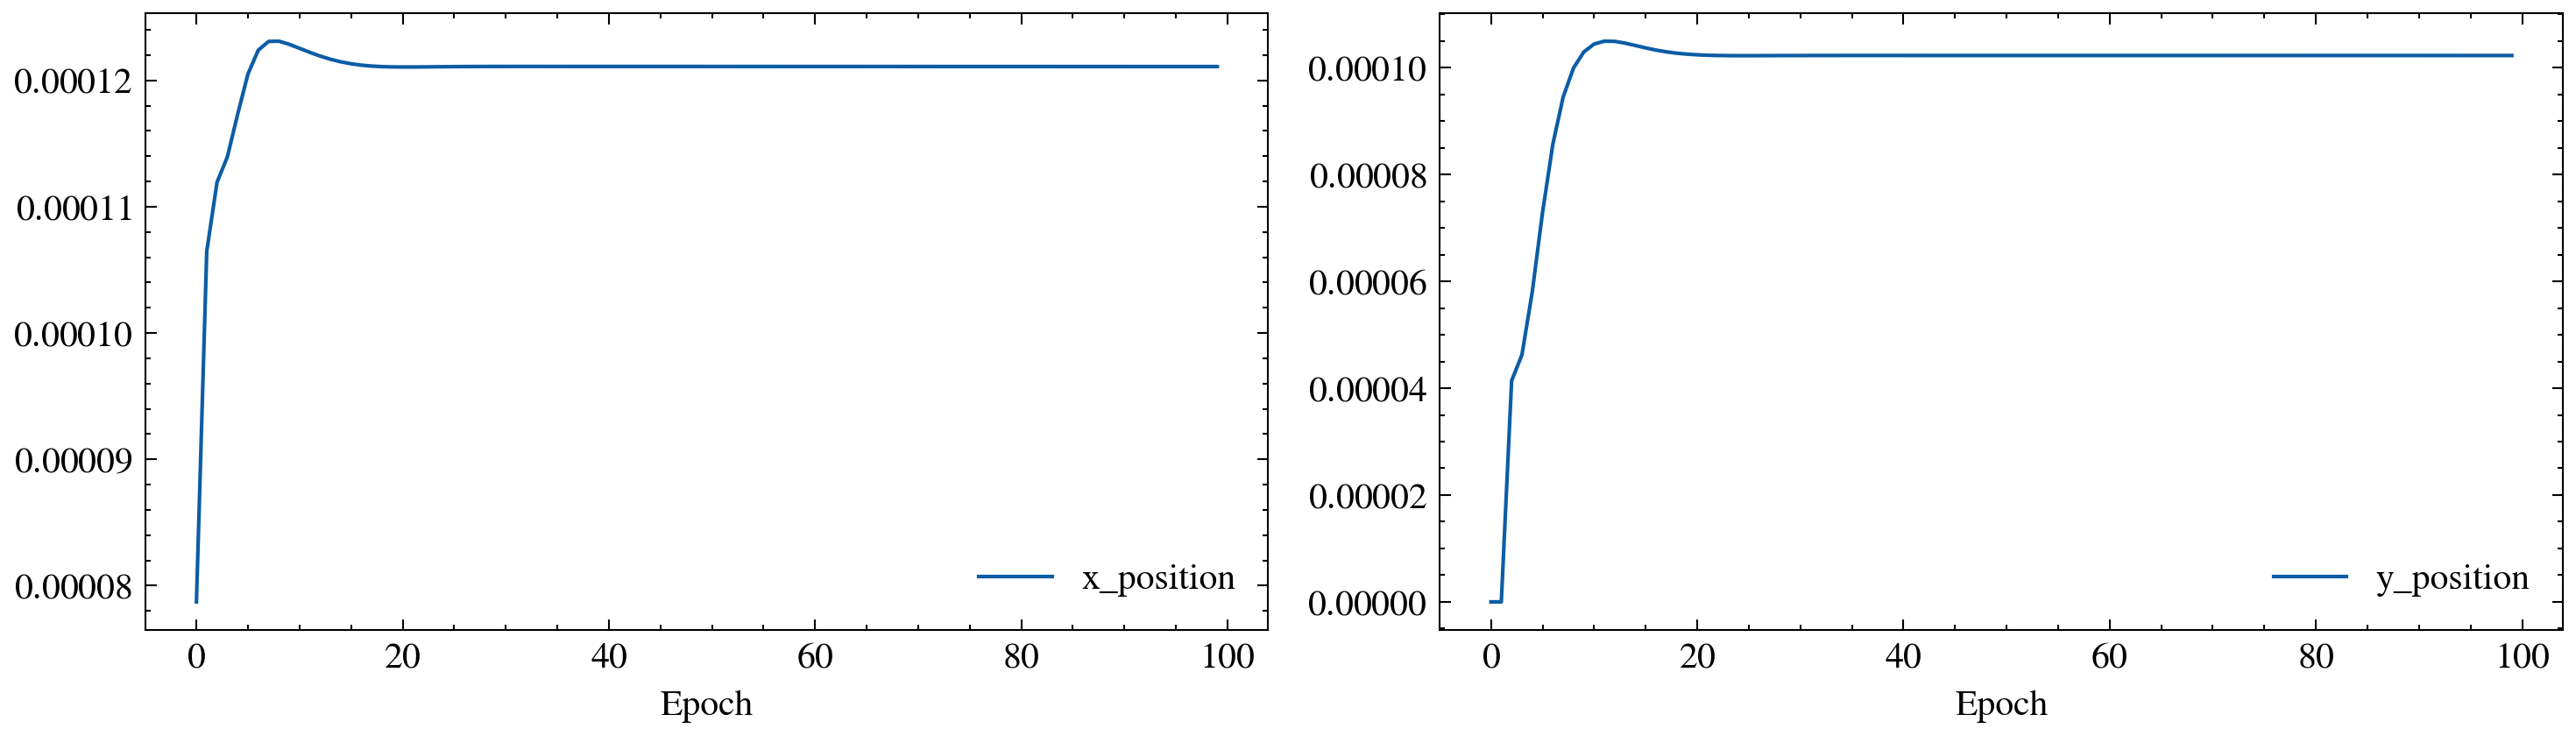

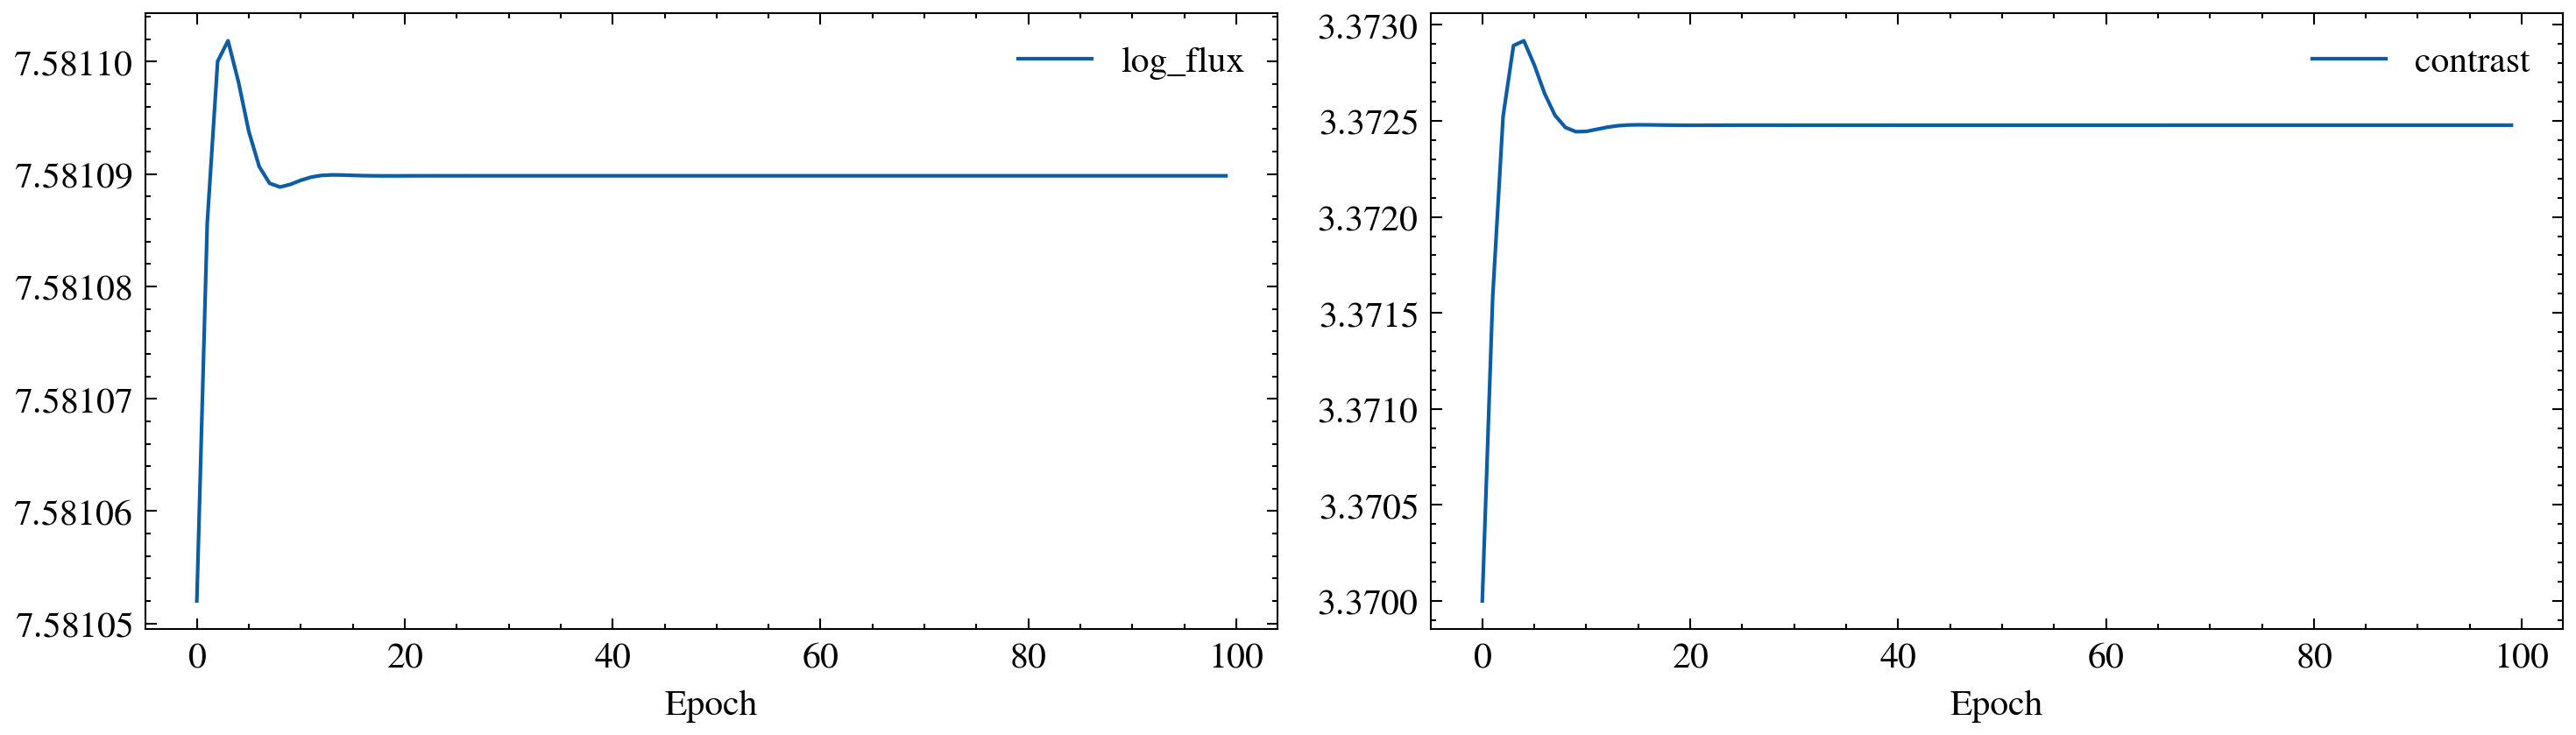

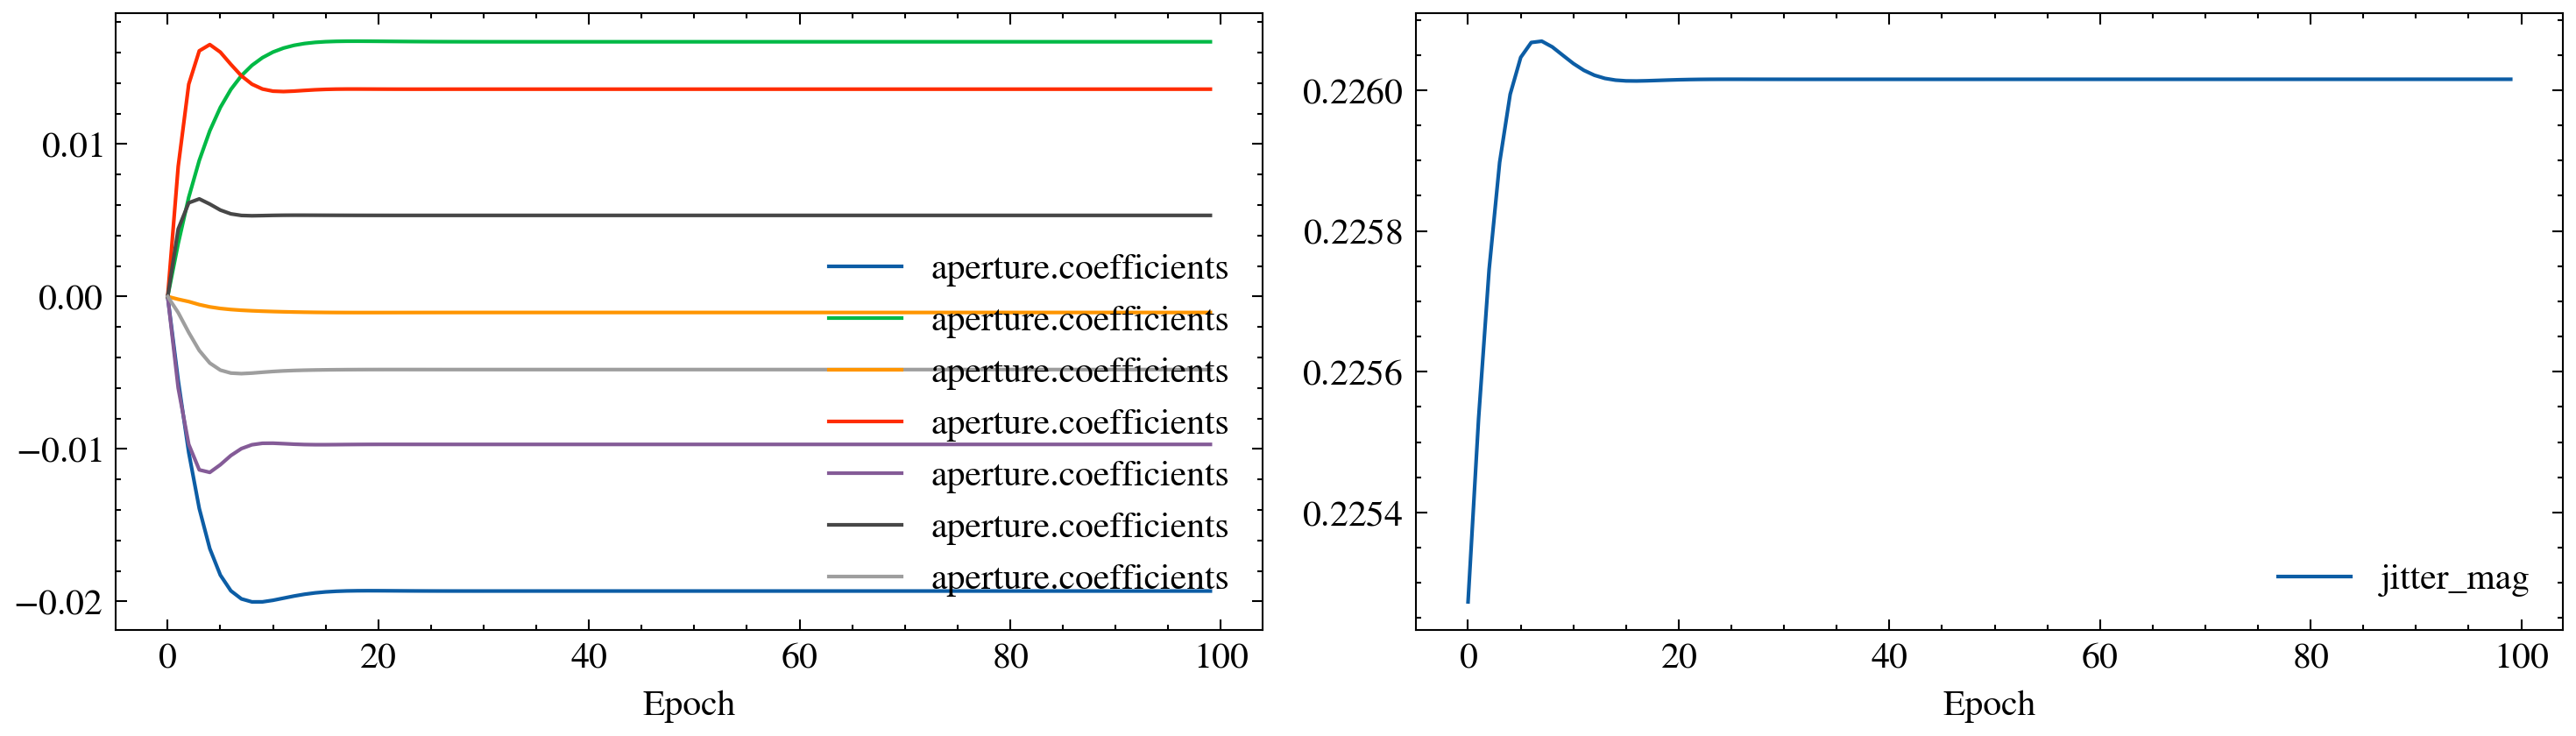

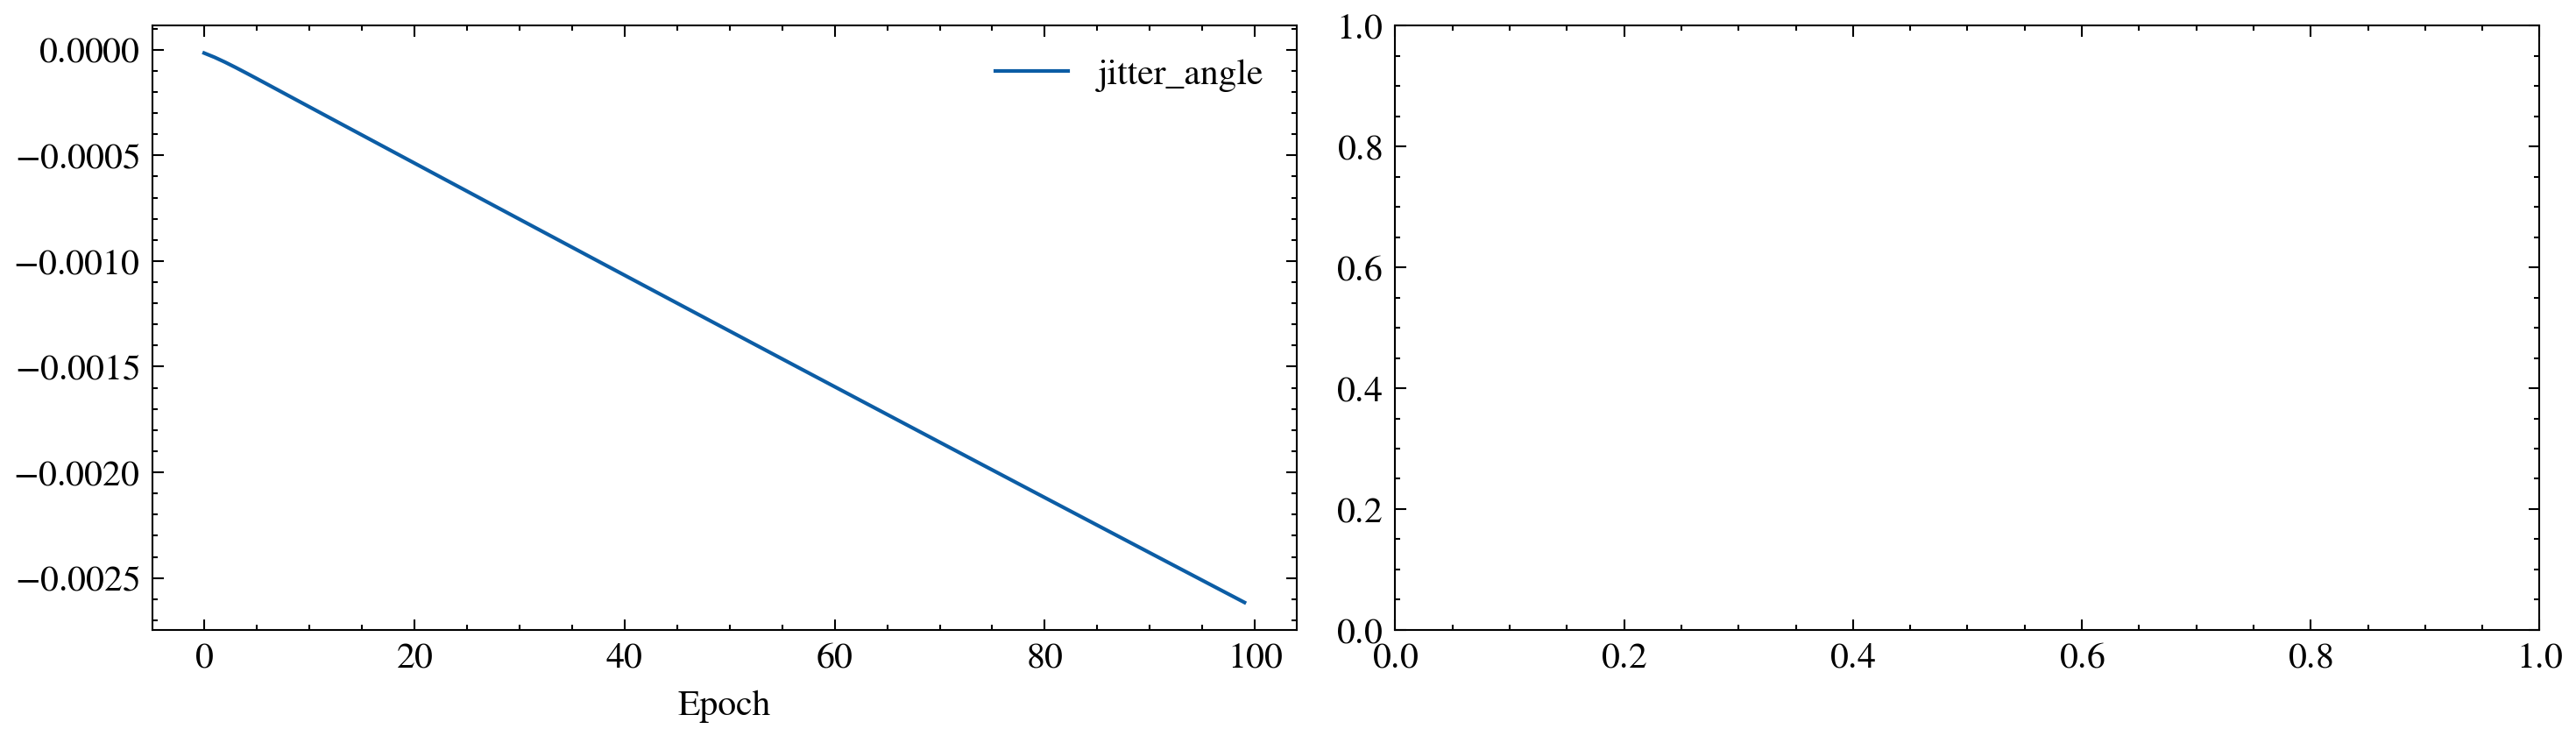

lin lin Realisation 4/5 ['jitter_mag', 'jitter_angle'] [Array(0.3, dtype=float64), Array(0., dtype=float64)]


Gradient Descent:   0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
from zodiax.optimisation import sgd, adam

sep_dict_save_dir = "files/sep_dicts_revise/"


sep_dict = {}
n_realisations = 50

# Gradient descent
common_optimisers = {
    "separation": sgd(1e-8, 0),
    "position_angle": sgd(3e-7, 3),
    "x_position": sgd(5e-9, 0),
    "y_position": sgd(5e-9, 2),
    "log_flux": sgd(2e-9, 0),
    "contrast": sgd(1e-6, 1),
    "aperture.coefficients": sgd(8e-5, 0),
}

lin_opts = {
    "jitter_mag": sgd(1e-7, 0),
    "jitter_angle": sgd(1e-5, 0),
}

norm_opts = {
    "Jitter.r": sgd(5e-3, 0),
    # "Jitter.shear": sgd(1e-7, 5),
    # "Jitter.shear": sgd(1e-6, 5),
    # "Jitter.phi": sgd(1e-5, 0),
}

# looping over modelså
for model_key in tqdm(models.keys(), desc="Models"):

    if model_key == "norm":
        optimisers = {**common_optimisers, **norm_opts}
    else:
        optimisers = {**common_optimisers, **lin_opts}

    model = models[model_key]
    posterior_fn = posterior_fns[model_key]

    # looping over data arrays
    for data_key in tqdm(datas.keys(), desc="Data Arrays"):
        # if data_key != "norm":
        #     continue
        # if data_key == "norm":
        #     continue
        # if data_key != "lin":
        #     continue
        # if model_key != "norm":
        #     continue
        # if model_key == "norm":
        # continue
        sep_values = np.array([], dtype=np.float64)

        # looping over noise realisations
        for i in tqdm(range(n_realisations), desc="Noise Realisations"):

            data_dict = datas[data_key][i % len(datas[data_key])]
            data = data_dict["data"]
            angle = data_dict["values"][1]
            if model_key == "norm" and data_key != "norm":
                model = model.set("Jitter.phi", angle)
            elif model_key != "norm" and data_key == "norm":
                model = model.set("jitter_angle", angle)
            else:
                model = model.set(data_dict["params"], data_dict["values"])
            noisy_data = jr.poisson(
                jr.PRNGKey(random.randint(0, int(1e8))),
                data,
            )
            # noisy_data = data
            args = {
                "data_dict": data_dict,
                "model_key": model_key,
                "data_key": data_key,
                "angle": angle,
                "optimisers": optimisers,
            }

            print(
                model_key,
                data_key,
                f"Realisation {i+1}/{n_realisations}",
                data_dict["params"],
                data_dict["values"],
            )
            # RUN GRAD DESCENT
            gd_model = run_grad_desc(
                model,
                noisy_data,
                args,
                optimisers=optimisers,
                norm_fn=norm_fn,
                grad_fn=grad_fn,
                iters=100,
                posterior_fn=posterior_fn,
                likelihood_im_fn=loglike_fns[model_key],
                eps=5e-4,
                plot=True,
            )

            sep_values = np.append(sep_values, gd_model.separation)
        sep_dict[f"{model_key}_{data_key}"] = sep_values

# saving
current_time = datetime.now().strftime("%d-%m-%Y_%H-%M")
save_str = current_time + f"_{n_realisations:04d}.npy"
np.save(os.path.join(sep_dict_save_dir, save_str), sep_dict)

In [ ]:
# model = models["norm"]
# data = datas["lin"]
# # data = datas["norm"]
# loglike_fn = loglike_fns["norm"]
# optimisers = {**common_optimisers, **norm_opts}

# noisy_data = jr.poisson(jr.PRNGKey(random.randint(0, int(1e8))), data)


# def normalisation_fn(model):
#     # return model.set("Jitter.r", np.array(1e-16))
#     return model.set("Jitter.r", np.clip(model.Jitter.r, 1e-16))


# gd_model = run_grad_desc(
#     model,
#     noisy_data,
#     optimisers=optimisers,
#     loglike_fn=loglike_fn,
#     norm_fn=normalisation_fn,
#     iters=500,
#     eps=1e-4,
#     plot=True,
# )

In [ ]:
total_sep_dict = {}
sep_dict_save_dir = "files/sep_dicts_revise/"

# looping over saved sep_dicts
for f in os.listdir(sep_dict_save_dir):
    if not f.endswith(".npy"):
        continue

    # loading each file
    this_dict = np.load(os.path.join(sep_dict_save_dir, f), allow_pickle=True).item()

    # appending to total_sep_dict
    for k in this_dict.keys():
        total_sep_dict[k] = (
            np.append(total_sep_dict[k], this_dict[k])
            if k in total_sep_dict.keys()
            else this_dict[k]
        )

In [ ]:
import numpy as onp


def bootstrap_histogram(histogram: Array, num_bootstraps: int) -> Array:
    """
    Perform bootstrapping on a histogram to get theuncertainty in the mean and standard deviation.
    """
    boot_means = []
    boot_stds = []

    for _ in range(num_bootstraps):
        resampled_data = onp.random.choice(
            histogram,
            size=len(histogram),
            replace=True,
        )
        boot_means.append(np.mean(resampled_data))
        boot_stds.append(np.std(resampled_data, ddof=1))

    # Compute statistics
    mean_estimate = np.mean(histogram)
    std_estimate = np.std(histogram)
    mean_uncertainty = np.std(np.array(boot_means))
    std_uncertainty = np.std(np.array(boot_stds))

    return mean_estimate, mean_uncertainty, std_estimate, std_uncertainty

In [ ]:
print(f"{len(list(total_sep_dict.values())[0])} noise realisations.")

n_bins = 30
true_sep = models["lin"].separation  # arcseconds
fontsize = 20
fisher_sigmas = {
    "lin": 1e-3 * 0.24839681897145435,
    "shm": 1e-3 * 0.24839681897145435,
}  # pre-calculated
titles = {"lin": "Linear", "shm": "SHM", "norm": "Normal"}


fig, ax = plt.subplots(
    3,
    3,
    figsize=(8.5, 4.5),
    sharex=True,
    sharey=True,
)
fig.subplots_adjust(
    top=0.915,
    bottom=0.106,
    left=0.074,
    right=0.985,
    hspace=0.0,
    wspace=0.0,
)

for i in range(3):
    for j in range(3):
        if i == 0:
            sigma_0 = fisher_sigmas["lin"]
        elif i == 1:
            sigma_0 = fisher_sigmas["shm"]

        key = f"{list(models.keys())[i]}_{list(datas.keys())[j]}"
        results = total_sep_dict[key]
        offset_hist = results - true_sep  # in arseconds
        offset_hist /= sigma_0  # converting to sigma units

        ax[i][j].hist(
            offset_hist,
            bins=n_bins,
            density=True,
            color=ito_seven[0],
            alpha=0.7,
            histtype="stepfilled",
            label="MLEs hist.",
        )
        ax[i][j].set(
            # title=f"{key}",
            xlim=(-4, 4),
            xticks=range(-3, 4),
            yticks=[],
        )

        ax[i][j].set_xticklabels(
            [
                r"$-3\sigma_0$",
                r"$-2\sigma_0$",
                r"$-\sigma_0$",
                "0",
                r"$\sigma_0$",
                r"$2\sigma_0$",
                r"$3\sigma_0$",
            ]
        )

        ax[i][j].minorticks_off()
        ax[i][j].tick_params(direction="out")
        ax[i][j].grid(True, alpha=0.5, linestyle="-")

        # # Bootstrapping to find mean, std and uncertainties of each
        # mu, dmu, std, dstd = bootstrap_histogram(offset_hist, 1000)

        # if we don't care about the uncertainties
        mu = np.mean(offset_hist)
        std = np.std(offset_hist)

        xmin, xmax = plt.xlim()

        xs = np.linspace(xmin, xmax, 100)
        bell_curve = jax.scipy.stats.norm.pdf(xs, mu, std)

        one_sigma_xs = np.linspace(mu - std, mu + std, 100)
        one_sigma_bell = jax.scipy.stats.norm.pdf(one_sigma_xs, mu, std)

        mean_max = jax.scipy.stats.norm.pdf(mu, mu, std)

        # Plot the normal distribution curve
        ax[i][j].plot(
            xs, bell_curve, ito_seven[1], linewidth=2, alpha=1.0, label="Gaussian fit"
        )
        ax[i][j].fill_between(
            one_sigma_xs,
            one_sigma_bell,
            color=ito_seven[1],
            alpha=0.4,
            zorder=1,
            label=r"$1\sigma$ region",
            linewidth=0,
        )

        if j != 1:
            ax[i][j].set_xlabel(None)
        else:
            ax[i][j].set_xlabel(
                r"Offset between recovered separation and truth",
                fontsize=0.7 * fontsize,
            )

        if j == 0:
            ax[i][j].set_ylabel(f"{titles[list(models.keys())[i]]}", fontsize=fontsize)

            if i == 0:
                legend = ax[i][i].legend(
                    fontsize=8, facecolor="white", loc="upper left"
                )

                # # This is just to create a blank space behind the legend
                rect = mpl.patches.Rectangle(
                    (0.02, 0.62),
                    0.355,
                    0.4,
                    fill=True,
                    edgecolor=None,
                    transform=ax[i][j].transAxes,
                    zorder=2,
                    color="white",
                )

                ax[i][j].add_patch(rect)

        else:
            ax[i][j].set(
                ylabel=None,
            )
        if i == 0:
            ax[i][j].set(
                xlabel=None,
            )
            ax[i][j].set_title(
                f"{titles[list(datas.keys())[j]]}", fontsize=fontsize
            )  # Set the text size of the title
            ax[i][j].tick_params(axis="x", which="both", top=False, direction="in")
        else:
            ax[i][j].set(
                title=None,
            )

plt.savefig("files/paper_figs/biases.pdf", dpi=500)
plt.show()